In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import uproot
import pandas as pd
from collections import OrderedDict
from common_utils import *
from visualize import *
from uncertainties import *
import fastjet as fj
import awkward as ak
import time
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
ibu_bins = OrderedDict()
ibu_bins["pT_l1"] = np.asarray([25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0])
ibu_bins["pT_l2"] = np.asarray([25.0, 50.0, 75.0, 100.0, 150.0, 200.0, 400.0])
ibu_bins["eta_l1"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["eta_l2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_l1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_l2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_trackj1"] = np.asarray([5.0, 50.0, 100.0, 150.0, 200.0, 300.0, 1000.0])
ibu_bins["pT_trackj2"] = np.asarray([5.0, 25.0, 50.0, 100.0, 500.0])
ibu_bins["y_trackj1"] = np.asarray([-2.5, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5])
ibu_bins["y_trackj2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_trackj1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_trackj2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_ll"] = np.asarray([200.0, 230.0, 300.0, 450.0, 600.0, 1000.0])
ibu_bins["y_ll"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["Ntracks_trackj1"] = np.asarray([0.5, 6.5, 10.5, 14.5, 19.5, 25.5, 39.5])
ibu_bins["Ntracks_trackj2"] = np.asarray([0.5, 3.5, 7.5, 11.5, 15.5, 34.5])
ibu_bins["m_trackj1"] = np.asarray([0.0, 8.0, 16.0, 24.0, 32.0, 42.0, 70.0])
ibu_bins["m_trackj2"] = np.asarray([0.0, 5.0, 10.0, 20.0, 40.0] )
ibu_bins["tau1_trackj1"] = np.asarray([0.0, 0.05, 0.1, 0.17, 0.25, 0.35, 0.4, 0.9])
ibu_bins["tau1_trackj2"] = np.asarray([0.0, 0.1, 0.2, 0.35, 0.5, 0.9])
ibu_bins["tau2_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.08, 0.12, 0.17, 0.25, 0.5])
ibu_bins["tau2_trackj2"] = np.asarray([0.0, 0.025, 0.1, 0.17, 0.25, 0.5])
ibu_bins["tau3_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.1, 0.3])
ibu_bins["tau3_trackj2"] = np.asarray([0.0, 0.025, 0.08, 0.14, 0.3])
ibu_bins["HT_tracks"] = np.asarray([0.0, 160.0, 235.0, 320.0, 440.0, 700.0, 1700.0])
ibu_bins["Ntracks"] = np.asarray([-0.5, 30.5, 60.5, 85.5, 115.5, 160.5])

#axs[0].set_ylim([0.2,600])

plot_labels = {
    "pT_l1"           : r"Leading lepton $p_{\text{T}}$ [GeV]",
    "pT_l2"           : r"Subleading lepton $p_\text{T}$ [GeV]",
    "eta_l1"          : r"Leading lepton $\eta$",
    "eta_l2"          : r"Subleading lepton $\eta$",
    "phi_l1"          : r"Leading lepton $\phi$",
    "phi_l2"          : r"Subleading lepton $\phi$",
    "pT_trackj1"      : r"Leading jet $p_{\text{T}}$ [GeV]",
    "pT_trackj2"      : r"Subleading jet $p_{\text{T}}$ [GeV]",
    "y_trackj1"       : r"Leading jet $y$",
    "y_trackj2"       : r"Subleading jet $y$",
    "phi_trackj1"     : r"Leading jet $\phi$",
    "phi_trackj2"     : r"Subleading jet $\phi$",
    "pT_ll"           : r"Dilepton $p_{\text{T}}$ [GeV]",
    "y_ll"            : r"Dilepton $y$",
    "Ntracks_trackj1" : r"Leading jet $n_\text{ch}$ ",
    "Ntracks_trackj2" : r"Subleading jet $n_\text{ch}$ ",
    "m_trackj1"       : r"Leading jet $m$ [GeV]",
    "m_trackj2"       : r"Subleading jet $m$ [GeV]",
    "tau1_trackj1"    : r"Leading jet $\tau_1$",
    "tau1_trackj2"    : r"Subleading jet $\tau_1$",
    "tau2_trackj1"    : r"Leading jet $\tau_2$",
    "tau2_trackj2"    : r"Subleading jet $\tau_2$",
    "tau3_trackj1"    : r"Leading jet $\tau_3$",
    "tau3_trackj2"    : r"Subleading jet $\tau_3$",
    "HT_tracks"       : r"$H_T$ [GeV]",
    "Ntracks"         : r"Charged Hadron Multiplicity, $n_\text{ch}$",
    "radial_profile_rho" : r"Distance from jet axis, $r$",
}

labels = {
     'pT_l1' : r'd$\sigma$/d$p_\text{T}^{\mu 1}$ [fb/GeV]',
     'pT_l2' : r'd$\sigma$/d$p_\text{T}^{\mu 2}$ [fb/GeV]',
     'eta_l1' : r'd$\sigma$/d$\eta^{\mu 1}$ [fb]',
     'eta_l2' : r'd$\sigma$/d$\eta^{\mu 2}$ [fb]',
     'phi_l1' : r'd$\sigma$/d$\phi^{\mu 1}$ [fb]',
     'phi_l2' : r'd$\sigma$/d$\phi^{\mu 2}$ [fb]',
     'pT_trackj1' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'pT_trackj2' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'y_trackj1' : r'd$\sigma$/d$y$ [fb]',
     'y_trackj2' : r'd$\sigma$/d$y$ [fb]',
     'phi_trackj1' : r'd$\sigma$/d$\phi$ [fb]',
     'phi_trackj2' : r'd$\sigma$/d$\phi$ [fb]',
     'pT_ll' : r'd$\sigma$/d$p_\text{T}^{\mu\mu}$ [fb/GeV]',
     'y_ll' : r'd$\sigma$/d$y^{\mu\mu}$ [fb]',
     'Ntracks_trackj1' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'Ntracks_trackj2' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'm_trackj1' : r'd$\sigma$/d$m$ [fb/GeV]',
     'm_trackj2' : r'd$\sigma$/d$m$ [fb/GeV]',
     'tau1_trackj1' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau1_trackj2' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau2_trackj1' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau2_trackj2' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau3_trackj1' : r'd$\sigma$/d$\tau_3$ [fb]',
     'tau3_trackj2' : r'd$\sigma$/d$\tau_3$ [fb]',
     'HT_tracks' : r'd$\sigma$/d$H_T$ [fb/GeV]',
     'Ntracks' : r'd$\sigma$/d$n_\text{ch}$ [fb]',
     "radial_profile_rho" : r"Avg. $p_T$ density, $\langle\rho\rangle$ [GeV]",

 }

mapping_mg = {
    "nominal": "weight_mc",
    "weights_theoryQCD": "QCD_dd",
    "weights_theoryPDF": "PDF_MSHT2020",
    "*weights_theoryAlphaS": "w_Alpha_s1",
    "*weights_theoryPSjet": "w_MPIDown",
    "*weights_theoryPSsoft": "w_RenDown",
    "*weights_theoryMPI": "w_Var1Down",
    "*weights_theoryPSscale": "w_Var2Down",
}

mapping_sh = {
    "nominal": "weight_mc",
    "weights_theoryQCD": "QCD_dd",
    "weights_theoryPDF": "PDF_MSHT2020",
    "weights_theoryAlphaS": "Alpha_s1",
    "*weights_theoryPSjet": "w_MPIDown",
    "*weights_theoryPSsoft": "w_RenDown",
    "*weights_theoryMPI": "w_Var1Down",
    "*weights_theoryPSscale": "w_Var2Down",
}

In [3]:
# Load all event data from ROOT files
f_mg = uproot.open("/Applications/PhD/Omni_Files_Kevin/jet_files/ZjetOmnifold_5Jul2025_MGPy8FxFxPlusNonStrong_syst_Test_withdd.root")
t_mg = f_mg["OmniTree"]
truth_pass190 = ak.to_numpy(t_mg["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t_mg["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

f_hv = uproot.open("/Applications/PhD/Omni_Files_Kevin/jet_files/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5.root")
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv   = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190_hv, truth_pT_ll_hv > 200)

f_mg_truth = uproot.open("/Applications/PhD/Omni_Files_Kevin/jet_files/ZjetOmnifold_26Mar26_MGPy8EGZJetsTruth_SlimedTo10Percent_w_theory.root")
t_mg_truth = f_mg_truth["OmniTree"]
truth_pass190_mg_truth = ak.to_numpy(t_mg_truth["truth_pass190"].array())
truth_pT_ll_mg_truth   = ak.to_numpy(t_mg_truth["truth_pT_ll"].array())
truth_pass200_mg_truth = np.logical_and(truth_pass190_mg_truth, truth_pT_ll_mg_truth > 200)

f_sh_truth = uproot.open("/Applications/PhD/Omni_Files_Kevin/jet_files/ZjetOmnifold_30Jul2025_Sherpa2211Truth_SlimedTo10Percent_w_theory.root")
t_sh_truth = f_sh_truth["OmniTree"]
truth_pass190_sh_truth = ak.to_numpy(t_sh_truth["truth_pass190"].array())
truth_pT_ll_sh_truth   = ak.to_numpy(t_sh_truth["truth_pT_ll"].array())
truth_pass200_sh_truth = np.logical_and(truth_pass190_sh_truth, truth_pT_ll_sh_truth > 200)

f_ns_truth = uproot.open("/Applications/PhD/Omni_Files_Kevin/jet_files/ZjetOmnifold_19Jun2025_NonStrong_posWrew_systJetIndex_Test.root")
t_ns_truth = f_ns_truth["OmniTree"]
truth_pass190_ns_truth = ak.to_numpy(t_ns_truth["truth_pass190"].array())
truth_pT_ll_ns_truth   = ak.to_numpy(t_ns_truth["truth_pT_ll"].array())
truth_pass200_ns_truth = np.logical_and(truth_pass190_ns_truth, truth_pT_ll_ns_truth > 200)

ibu_data_jet_obs = "/Applications/PhD/Omni_Files_Kevin/json_outfiles/IBU_data_pass200andSideBin_jetVars_16Mar26_TestSamples.json"
ibu_data_nom_obs = "/Applications/PhD/Omni_Files_Kevin/json_outfiles/IBU_data_pass200andSideBin_nomVars_16Mar26_TestSamples.json"
ibu_pd_jet_obs   = "/Applications/PhD/Omni_Files_Kevin/json_outfiles/IBU_pseudodata_pass200andSideBin_jetVars_16Mar26_TestSamples.json"
ibu_pd_nom_obs   = "/Applications/PhD/Omni_Files_Kevin/json_outfiles/IBU_pseudodata_pass200andSideBin_nomVars_16Mar26_TestSamples.json"



In [4]:

# Load event weights for pseudodata measurement
is_data = False

# Load event weights for Omnifold data measurement. These get attahed to events in madgraph_events.root
data_weights    = pd.read_hdf( "/Applications/PhD/Omni_Files_Kevin/after_muon_fix/data-weights-unshuffled.h5", key="weights", mode="r",)
data_hv_weights = pd.read_hdf( "/Applications/PhD/Omni_Files_Kevin/after_muon_fix/data-weights-unshuffled.h5", key="hv_weights", mode="r",)

# # Load all weights from the Omnifold pseudodata measurement.  These get attahed to events in madgraph_events.root
pseudodata_weights    = pd.read_hdf( "/Applications/PhD/Omni_Files_Kevin/after_muon_fix/pd-weights-unshuffled.h5", key="weights", mode="r",)
pseudodata_hv_weights = pd.read_hdf( "/Applications/PhD/Omni_Files_Kevin/after_muon_fix/pd-weights-unshuffled.h5", key="hv_weights", mode="r",)


if is_data:
    omnifold_weight_file = data_weights
    omnifold_hv_weight_file = data_hv_weights
else:
    omnifold_weight_file = pseudodata_weights
    omnifold_hv_weight_file = pseudodata_hv_weights

# Create dictionary describing all of the histograms needed for the pseudodata measurement
n_init_weights = [name for name in omnifold_weight_file.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in omnifold_weight_file.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in omnifold_weight_file.keys() if "weights_bootstrap_mc_" in name]
omni_weights = {
    # "prior": madgraph_weights["weights_nominal"][truth_pass200 == 1],
    "nominal": omnifold_weight_file["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": omnifold_weight_file[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": omnifold_weight_file[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": omnifold_weight_file[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": omnifold_weight_file["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": omnifold_weight_file["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": omnifold_weight_file["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": omnifold_weight_file["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": omnifold_weight_file["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": omnifold_weight_file["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": omnifold_weight_file["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    # "muCalScale": omnifold_weight_file["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": omnifold_weight_file["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": omnifold_weight_file["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": omnifold_weight_file["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": omnifold_weight_file["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    # "pileup": omnifold_weight_file["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": omnifold_weight_file["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": omnifold_weight_file["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": omnifold_weight_file["target_dd"].to_numpy()[truth_pass200 == 1],
    "hvhad": omnifold_weight_file["weights_hvhad"].to_numpy()[truth_pass200 == 1],
}

hv_weights = {  "nominal": omnifold_hv_weight_file["weights_hv"].to_numpy()[truth_pass200_hv == 1]}

# truth_pseudodata_weights = pd.read_hdf("/Applications/PhD/Omni_Files_Kevin/final_public_data/truth_pseudodata_weights.h5")
#truth_pd_weights = { "truthpd": ak.to_numpy(truth_pseudodata_weights["weight_mc"].array())[truth_pass200_pd == 1]}



In [5]:

mg_truth_weights = {
    key: np.array(t_mg_truth[branch])[truth_pass200_mg_truth]
    for key, branch in mapping_mg.items()
}

mg_truth_weights = append_ns_weights_with_theory(
    mg_truth_weights,
    t_mg_truth,
    t_ns_truth,
    truth_pass200_mg_truth,
    truth_pass200_ns_truth
)

sh_truth_weights = {
    key: np.array(t_sh_truth[branch])[truth_pass200_sh_truth]
    for key, branch in mapping_sh.items()
}

sh_truth_weights = append_ns_weights_with_theory(
    sh_truth_weights,
    t_sh_truth,
    t_ns_truth,
    truth_pass200_sh_truth,
    truth_pass200_ns_truth
)



In [6]:
features      = ["pT_l1", "pT_l2", "eta_l1", "eta_l2", "phi_l1", "phi_l2", "pT_trackj1", "pT_trackj2", "y_trackj1", "y_trackj2", "phi_trackj1", "phi_trackj2", "pT_ll", "y_ll", "Ntracks_trackj1", "Ntracks_trackj2", "m_trackj1", "m_trackj2", "tau1_trackj1", "tau1_trackj2", "tau2_trackj1", "tau2_trackj2", "tau3_trackj1", "tau3_trackj2", "HT_tracks", "Ntracks"]
features_ylog = {
    "pT_l1": True,
    "pT_l2": True,
    "eta_l1": False,
    "eta_l2": False,
    "phi_l1": False,
    "phi_l2": False,
    "pT_trackj1": True,
    "pT_trackj2": True,
    "y_trackj1": False,
    "y_trackj2": False,
    "phi_trackj1": False,
    "phi_trackj2": False,
    "pT_ll": True,
    "y_ll": False,
    "Ntracks_trackj1": False,
    "Ntracks_trackj2": False,
    "m_trackj1": True,
    "m_trackj2": True,
    "tau1_trackj1": True,
    "tau1_trackj2": True,
    "tau2_trackj1": True,
    "tau2_trackj2": True,
    "tau3_trackj1": True,
    "tau3_trackj2": True,
    "HT_tracks": True,
    "Ntracks": False,
}

omni_features     = {
    feature: np.array(t_mg["truth_"+feature])[truth_pass200 == 1] 
    for feature in features
}

hv_features     = {
    feature: np.array(t_hv["truth_"+feature])[truth_pass200_hv == 1] 
    for feature in features
}

mg_truth_features = {
    feature: np.array(t_mg_truth["truth_"+feature])[truth_pass200_mg_truth]
    for feature in features
}

sh_truth_features = {
    feature: np.array(t_sh_truth["truth_"+feature])[truth_pass200_sh_truth]
    for feature in features
}


# Load NS nominal weights and append them to MG 
ns_nominal = np.array(t_ns_truth["weight_mc"])[truth_pass200_ns_truth]
# append to MG/Sh truth weights
for feature in features:
        ns_feature                 = np.array(t_ns_truth["truth_"+feature])[truth_pass200_ns_truth]
        mg_truth_features[feature] = np.concatenate([ mg_truth_features[feature], ns_feature ])
        sh_truth_features[feature] = np.concatenate([ sh_truth_features[feature], ns_feature ])

       


In [7]:
omni_features_results = make_hists_with_uncertainty(
  data         = omni_features,
  bins         = ibu_bins, 
  observables  = features, 
  weights_dict = omni_weights
)



In [8]:
hv_features_results = make_hists_with_uncertainty(
  data         = hv_features,
  bins         = ibu_bins, 
  observables  = features, 
  weights_dict = hv_weights
)
# this just takes the uotput histogram from the hv run, and stores it as a variation on nom in the Omni result, so it can be treated as a syst error later.
for obs, weights in hv_features_results.items():
    if "nominal" in weights:
        omni_features_results.setdefault(obs, {})["hv"] = weights["nominal"]

In [9]:
mg_truth_features_results = make_hists_with_uncertainty(
  data         = mg_truth_features,
  bins         = ibu_bins, 
  observables  = features, 
  weights_dict = mg_truth_weights
)

In [10]:
sh_truth_features_results = make_hists_with_uncertainty(
  data         = sh_truth_features,
  bins         = ibu_bins, 
  observables  = features, 
  weights_dict = sh_truth_weights
)

In [11]:
ibu_results = {
    feature: json_to_hist(ibu_data_nom_obs, bins = ibu_bins[feature], var=feature)
    for feature in features
}

reading json for pT_l1
reading json for pT_l2
reading json for eta_l1
reading json for eta_l2
reading json for phi_l1
reading json for phi_l2
reading json for pT_trackj1
reading json for pT_trackj2
reading json for y_trackj1
reading json for y_trackj2
reading json for phi_trackj1
reading json for phi_trackj2
reading json for pT_ll
reading json for y_ll
reading json for Ntracks_trackj1
reading json for Ntracks_trackj2
reading json for m_trackj1
reading json for m_trackj2
reading json for tau1_trackj1
reading json for tau1_trackj2
reading json for tau2_trackj1
reading json for tau2_trackj2
reading json for tau3_trackj1
reading json for tau3_trackj2
reading json for HT_tracks
reading json for Ntracks


/Applications/PhD/Omnifold_ipynb/zjets_omnifold/analyze/visualize.py:1170: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


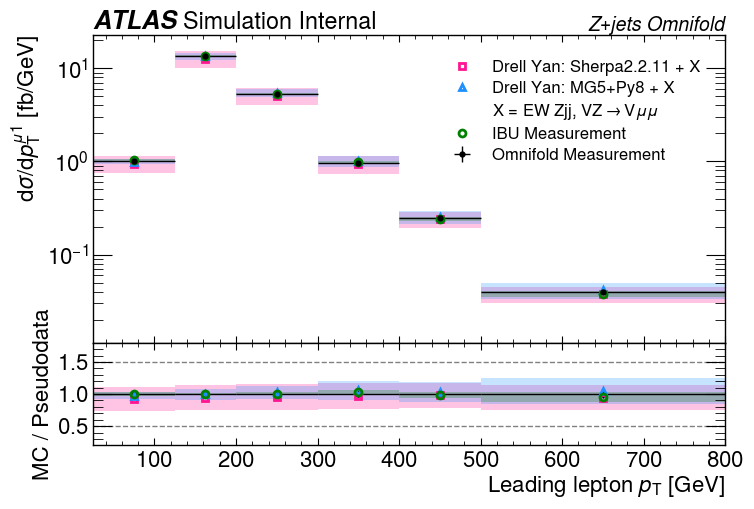

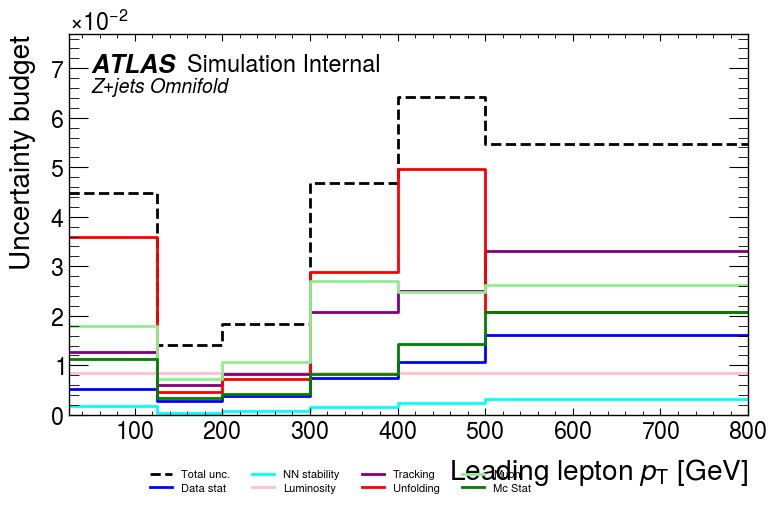

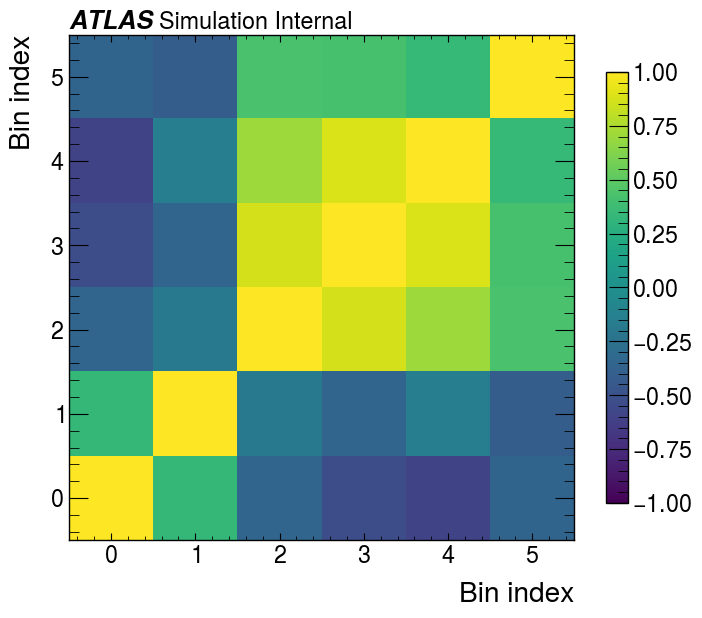

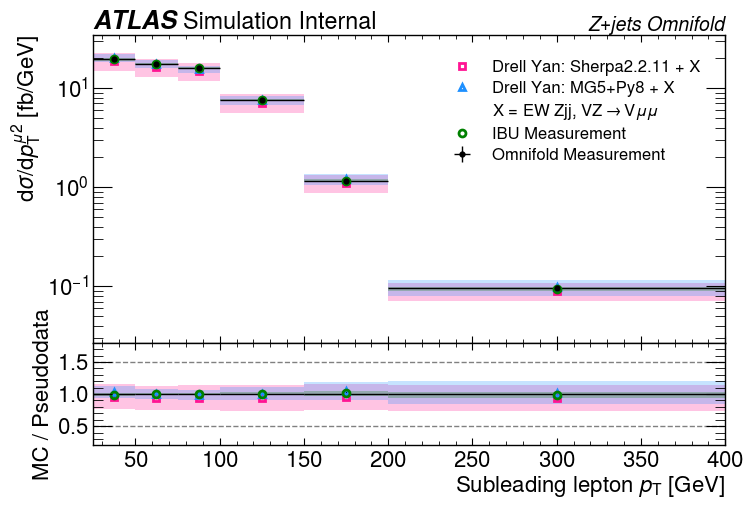

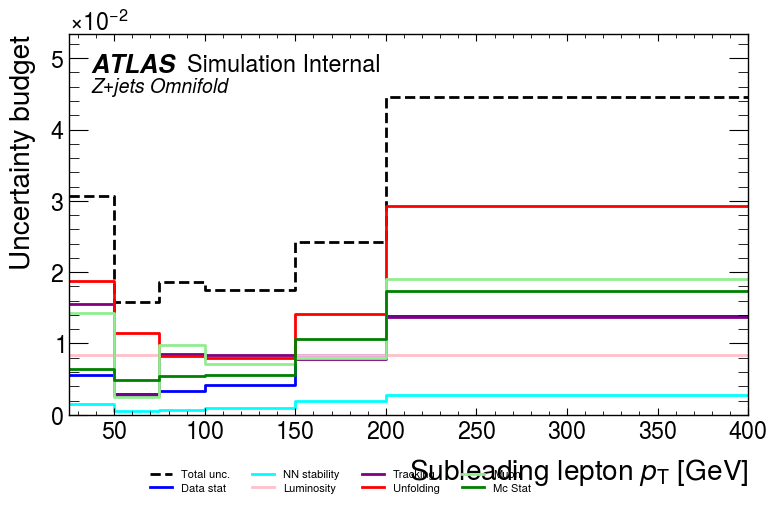

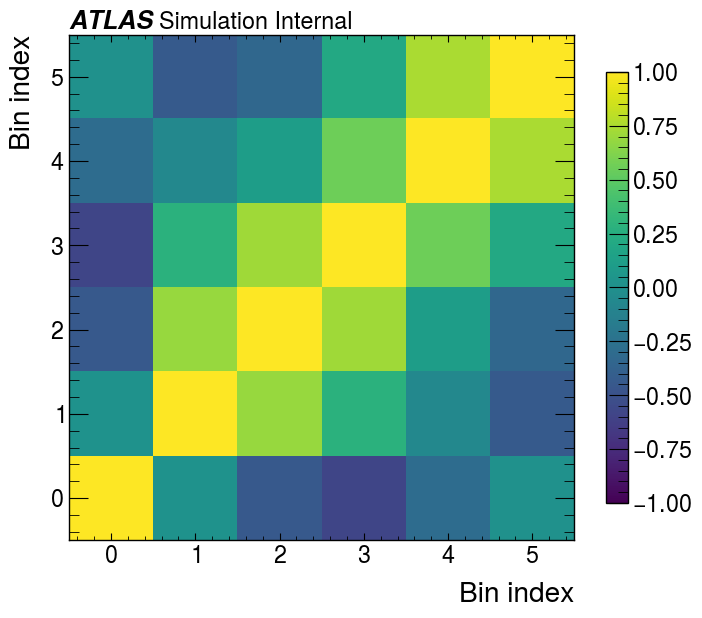

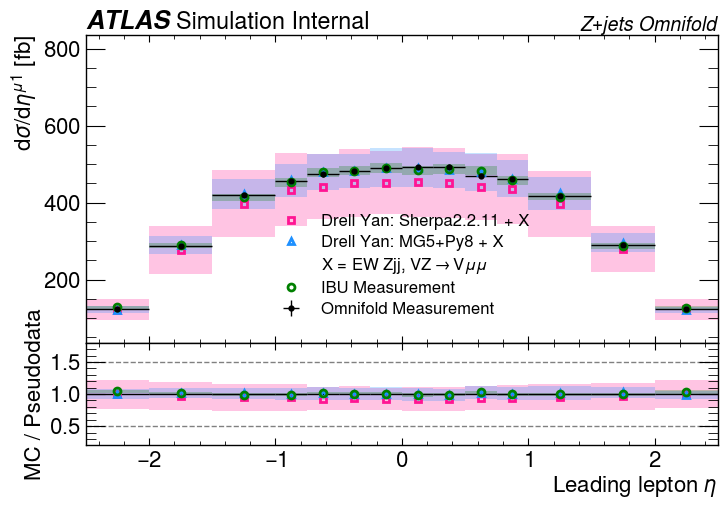

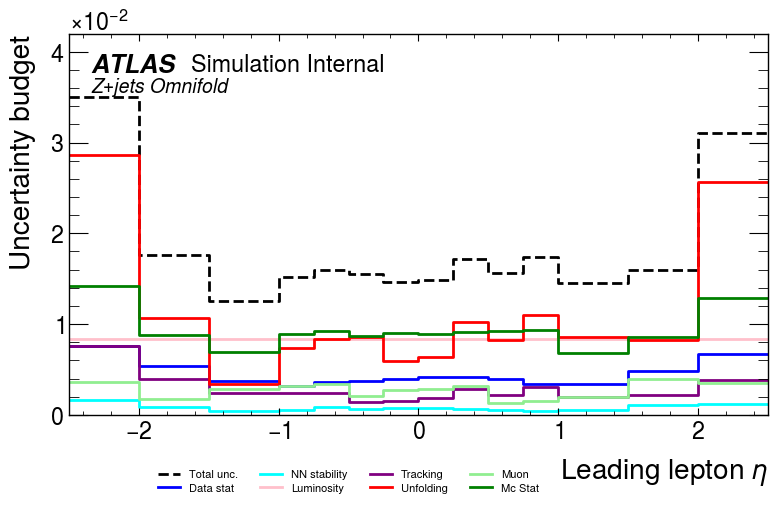

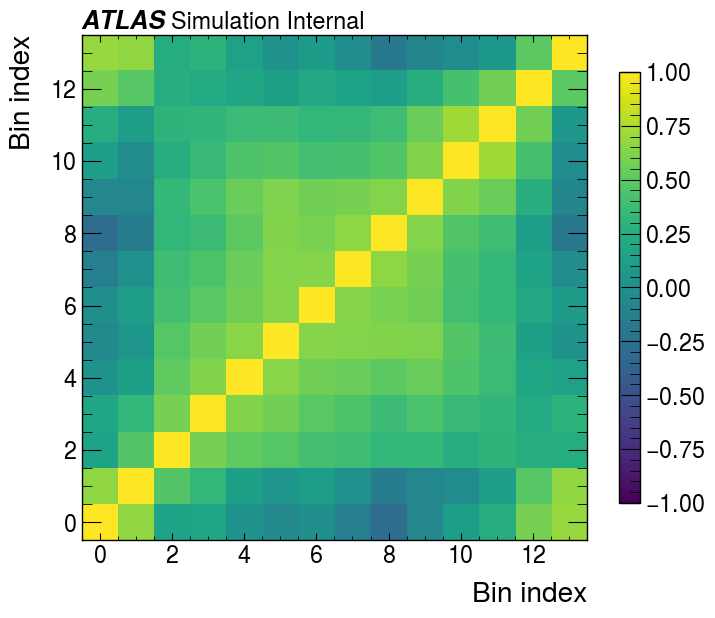

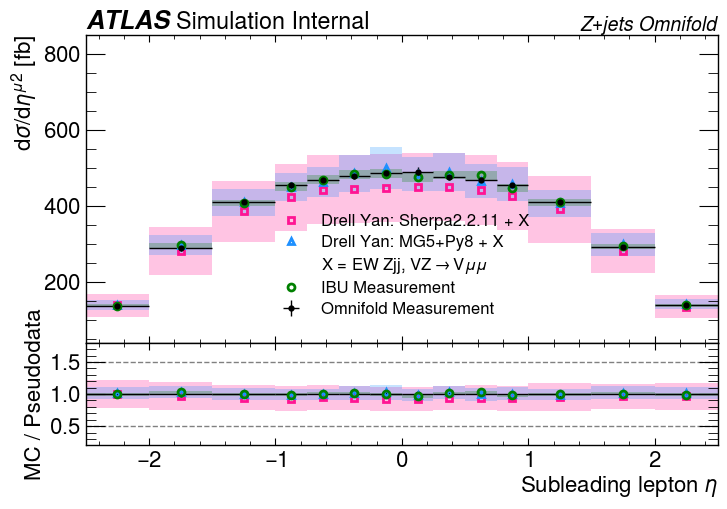

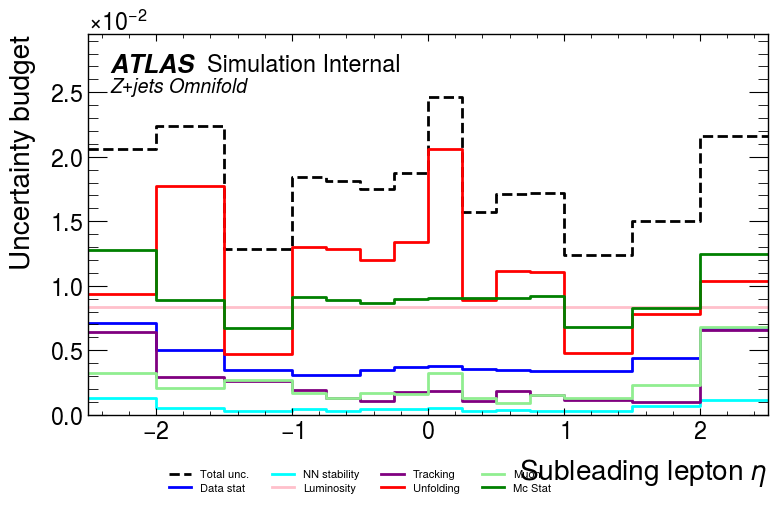

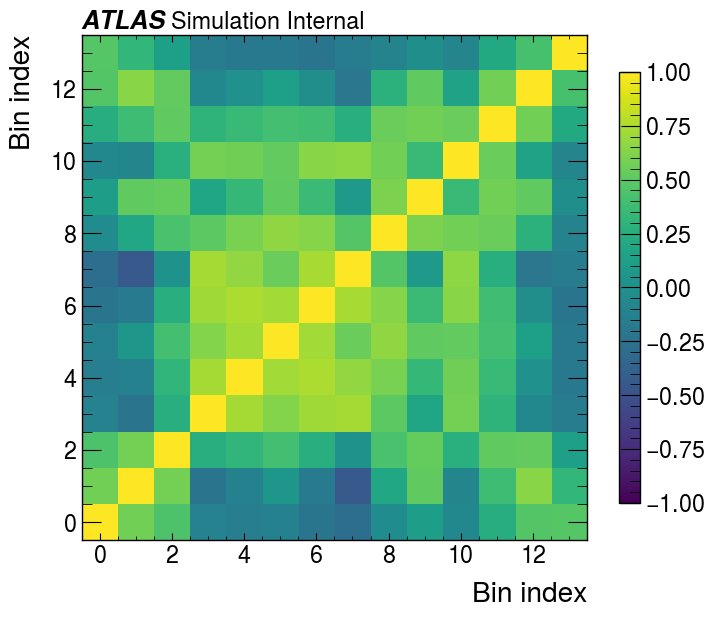

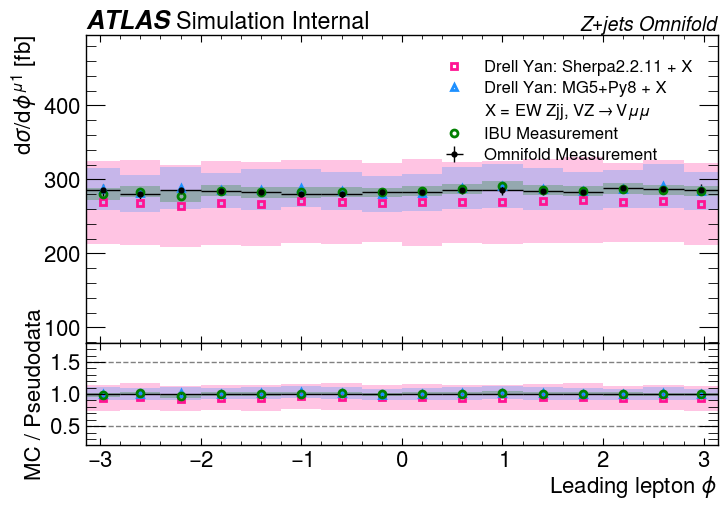

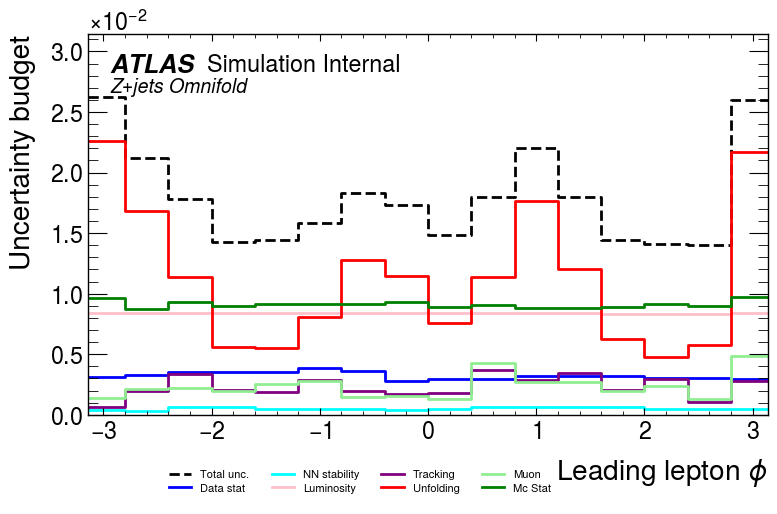

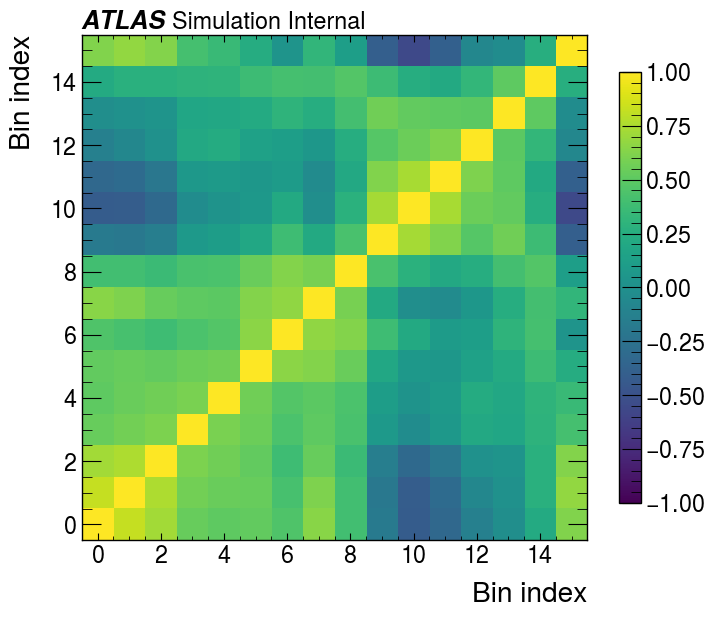

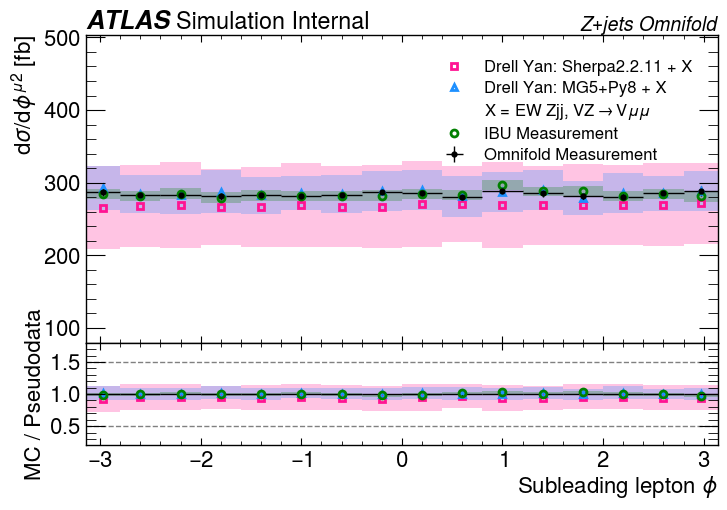

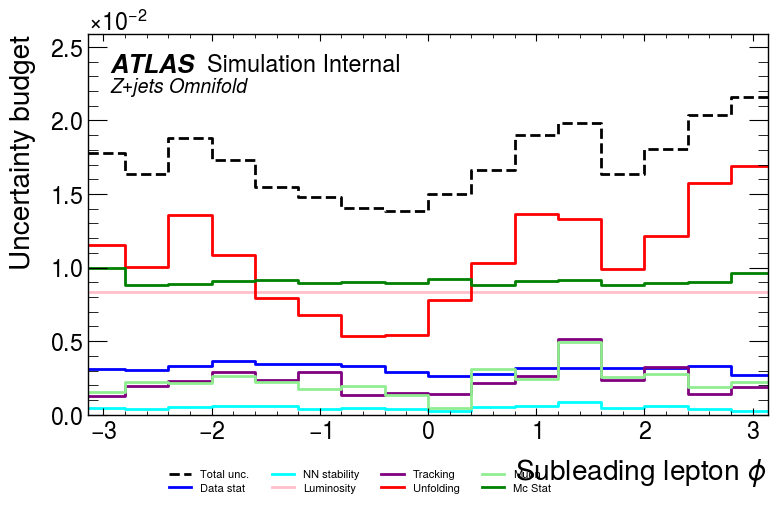

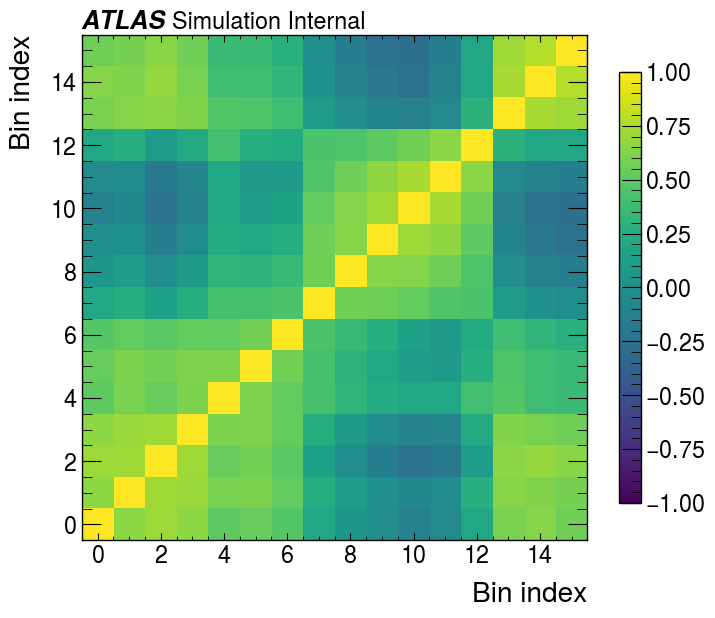

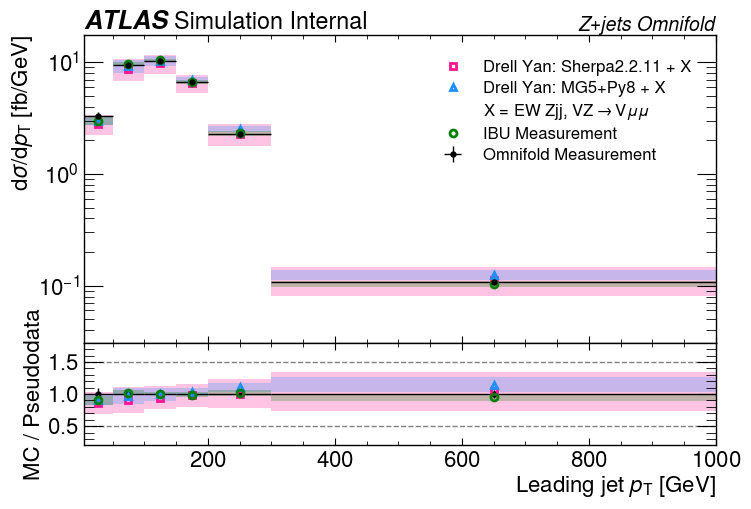

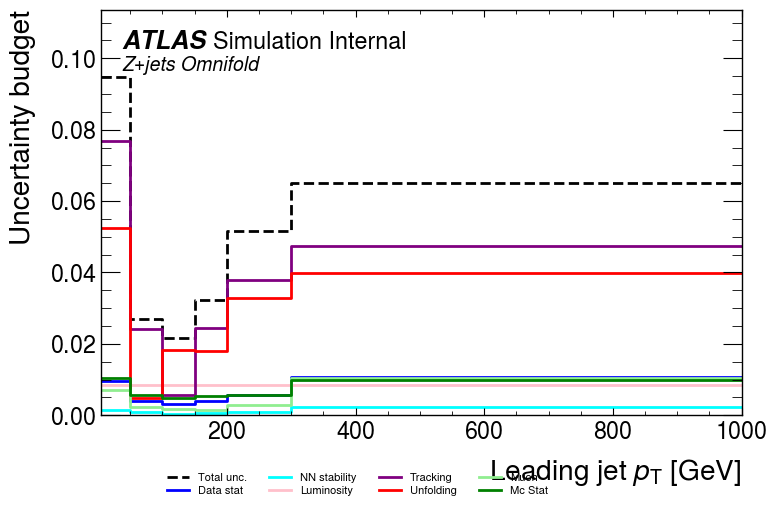

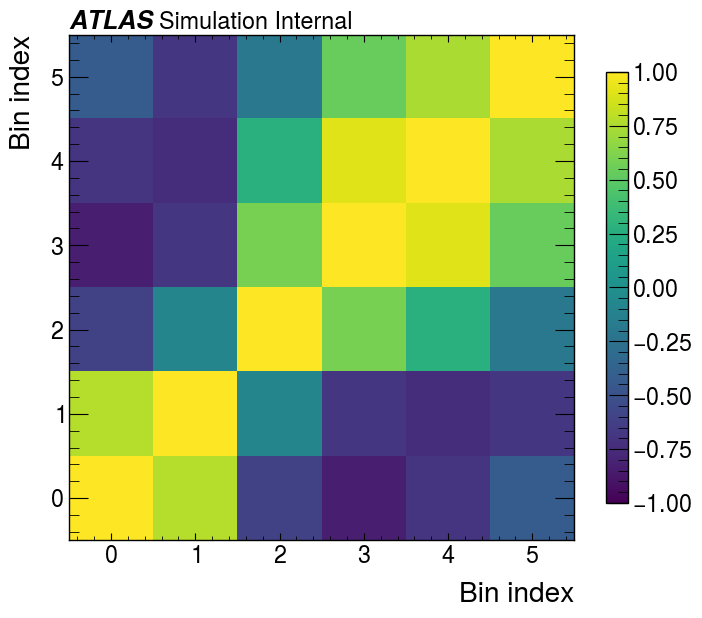

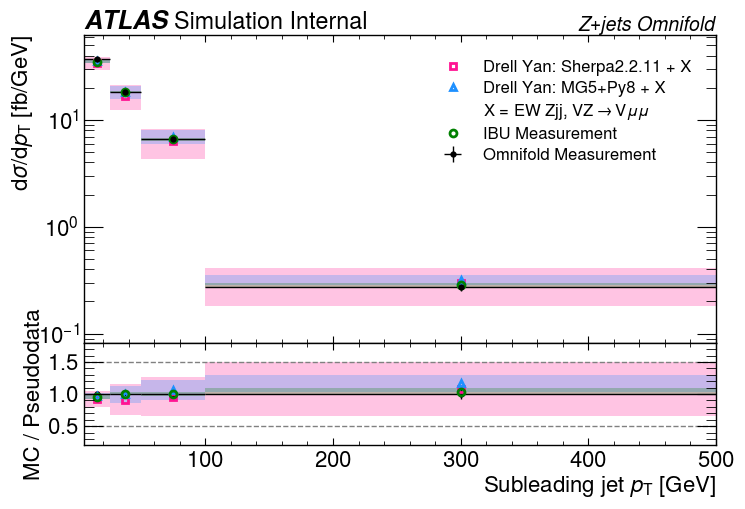

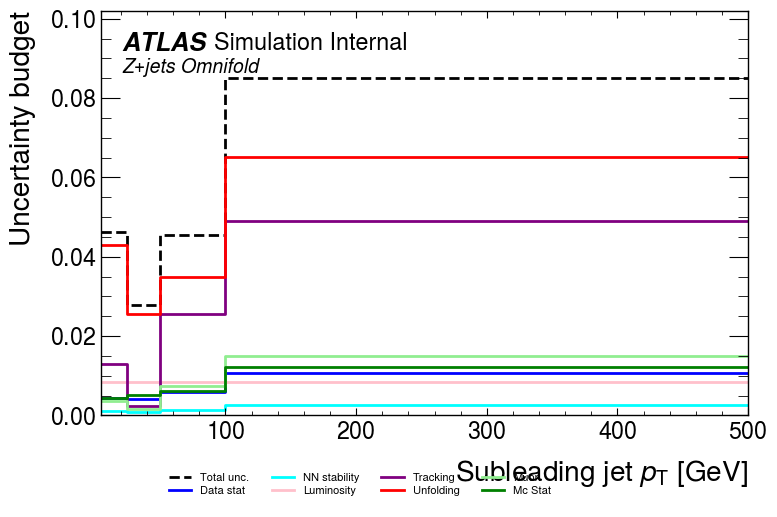

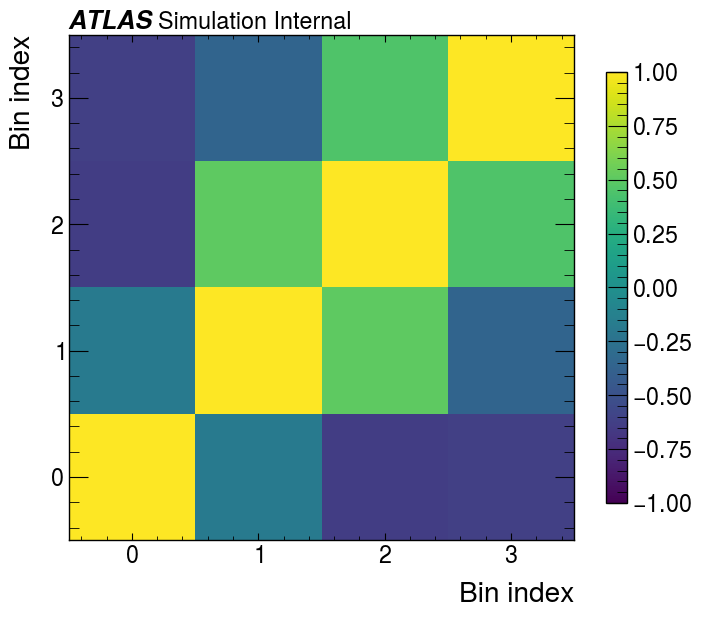

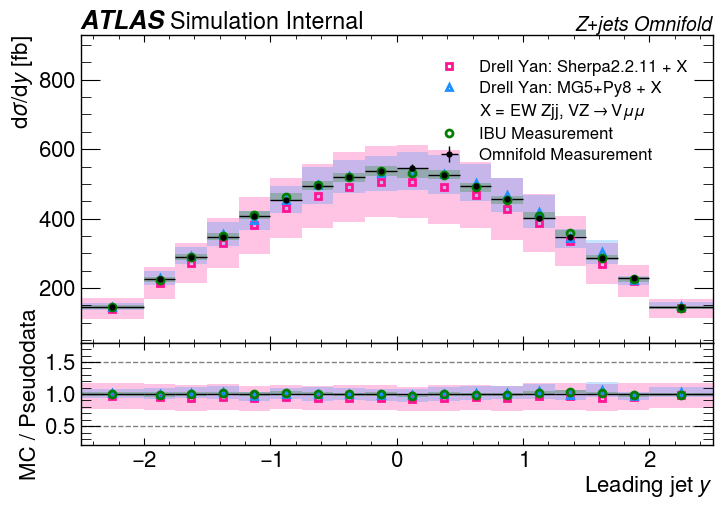

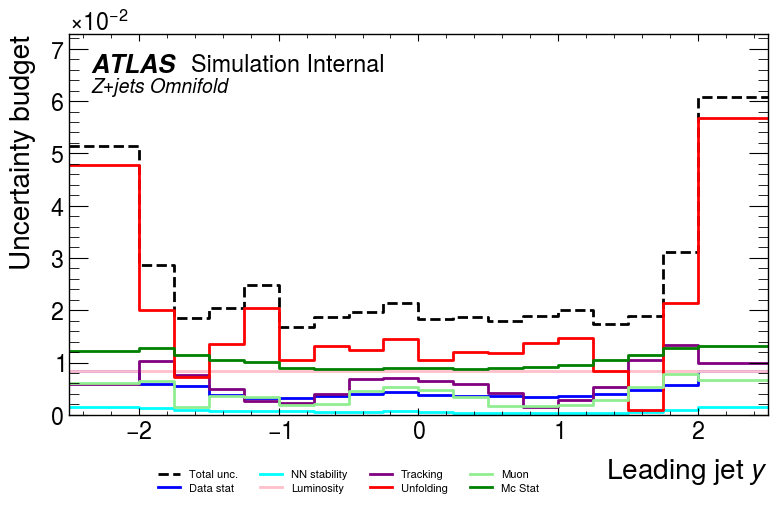

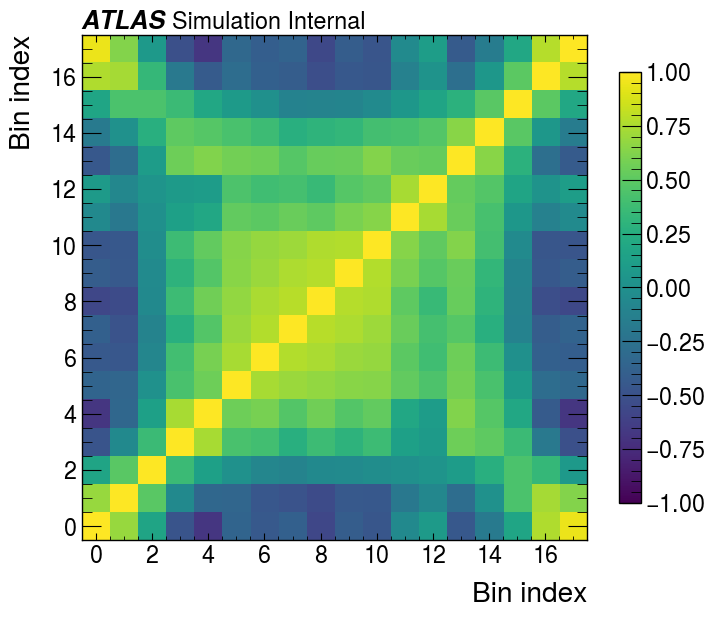

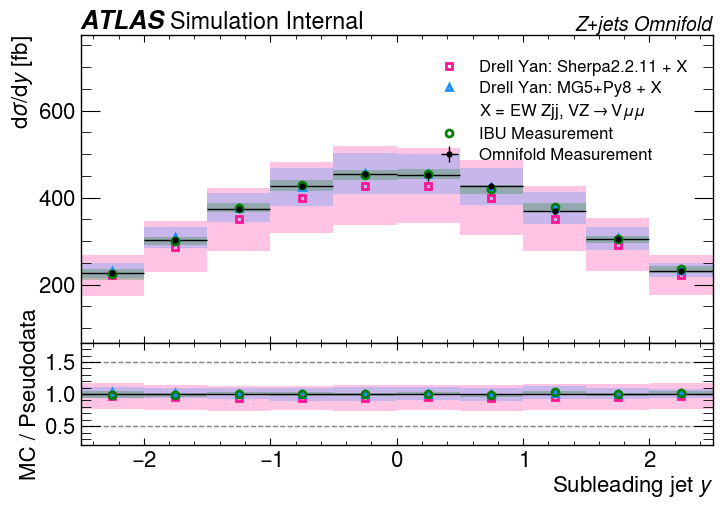

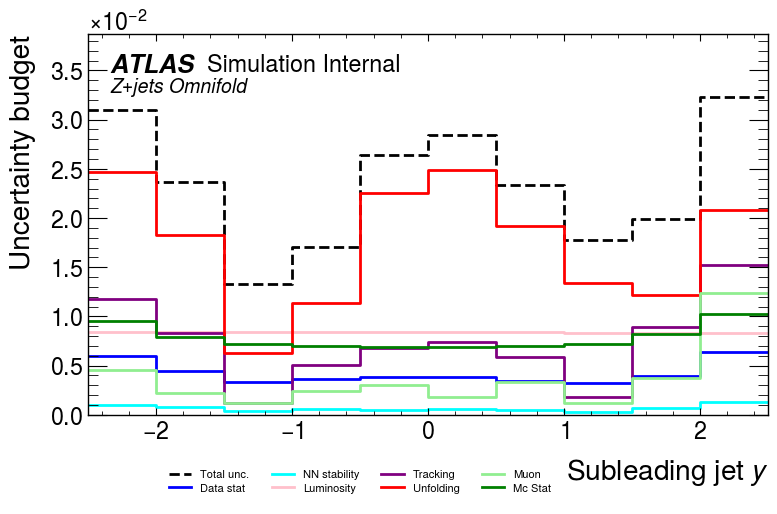

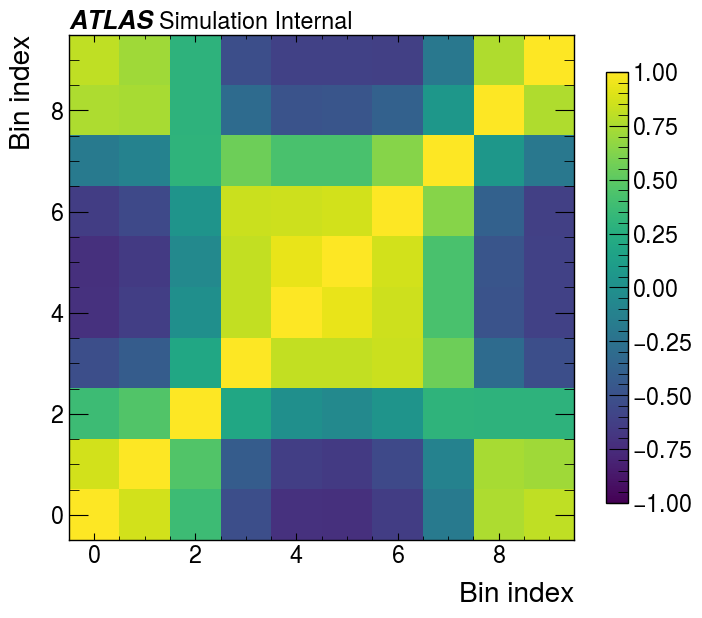

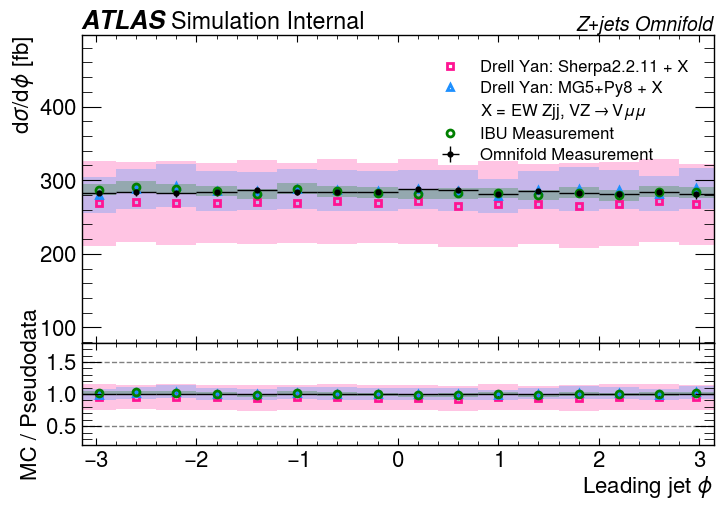

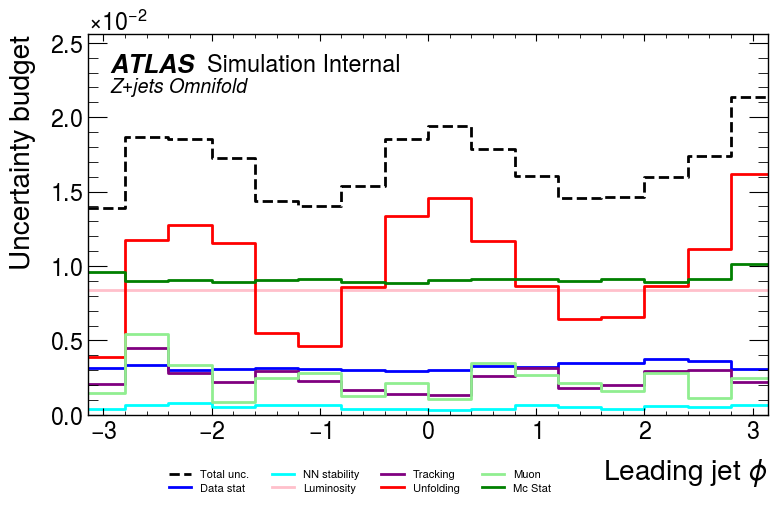

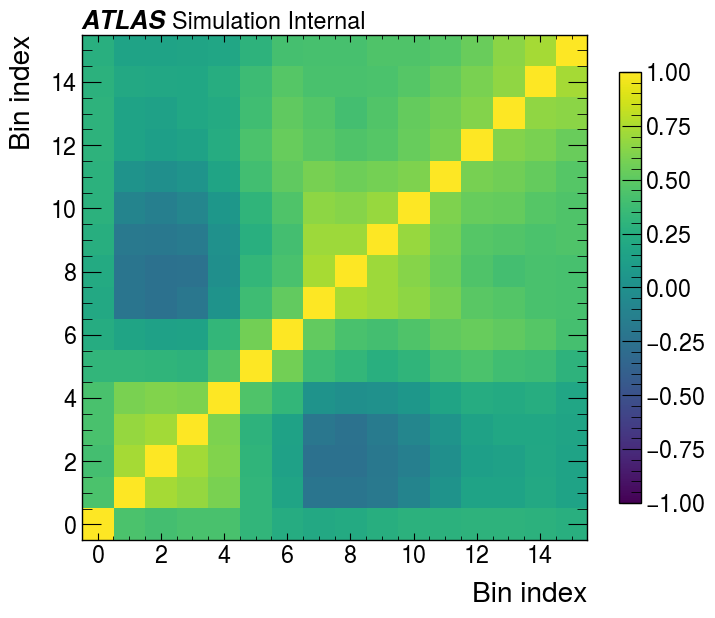

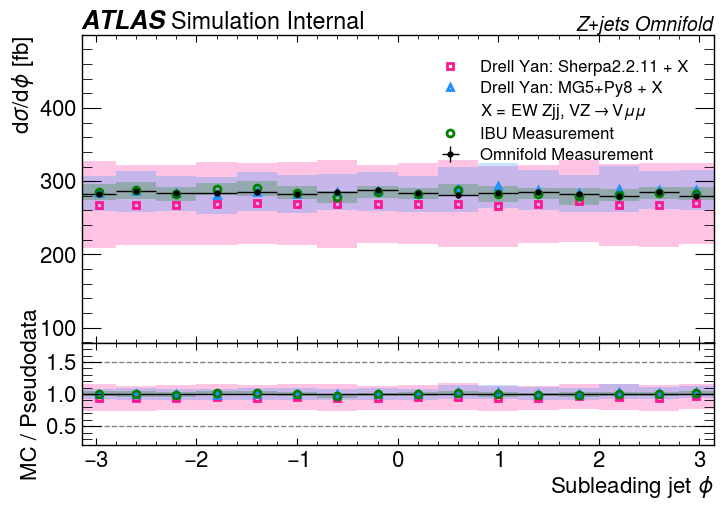

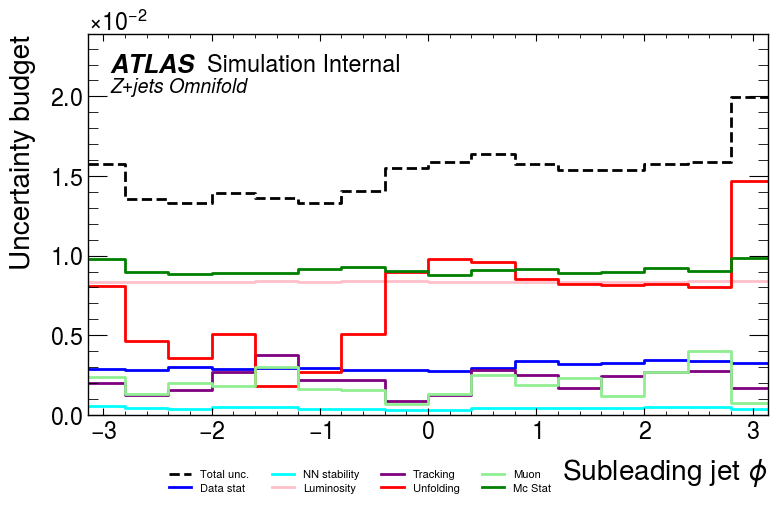

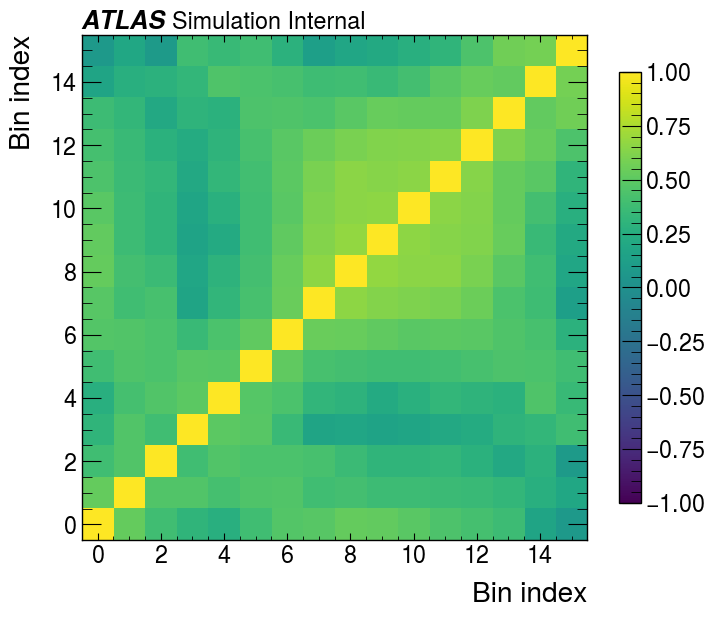

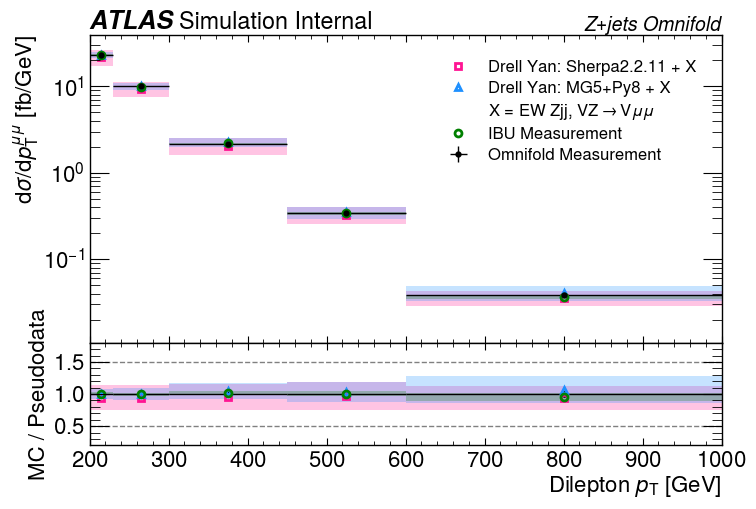

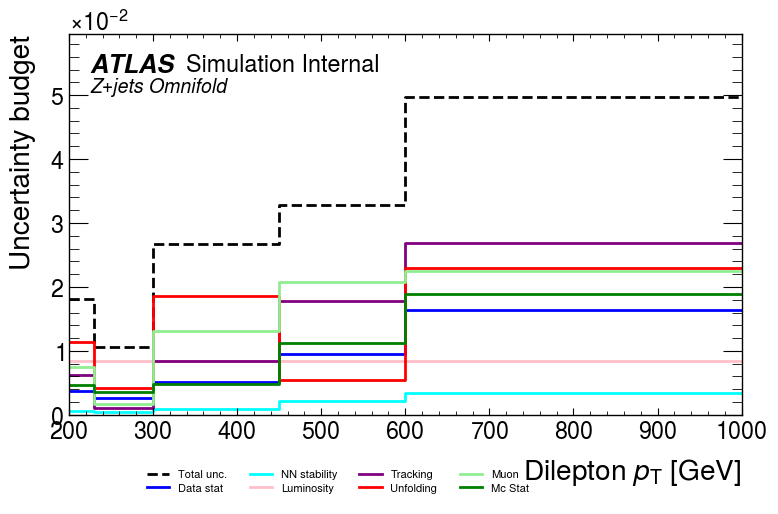

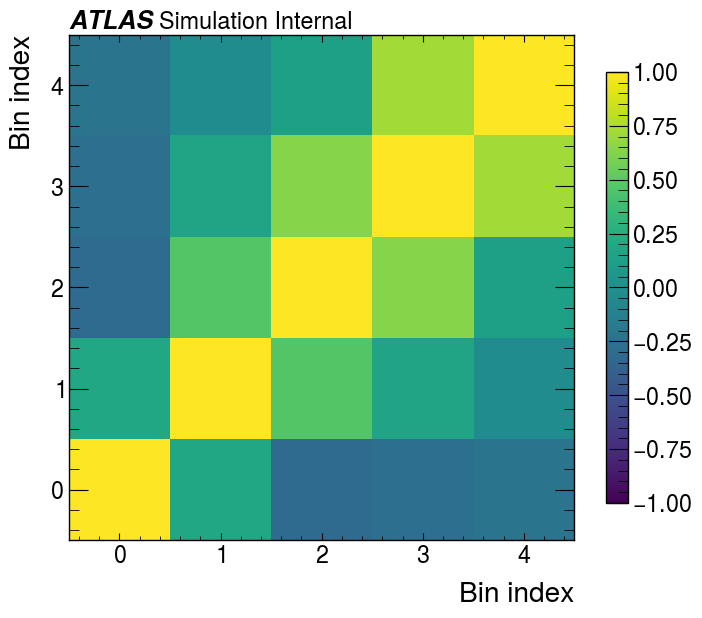

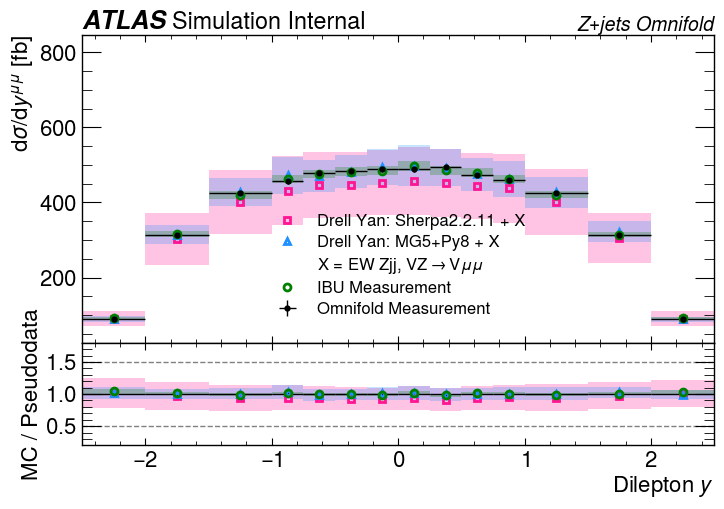

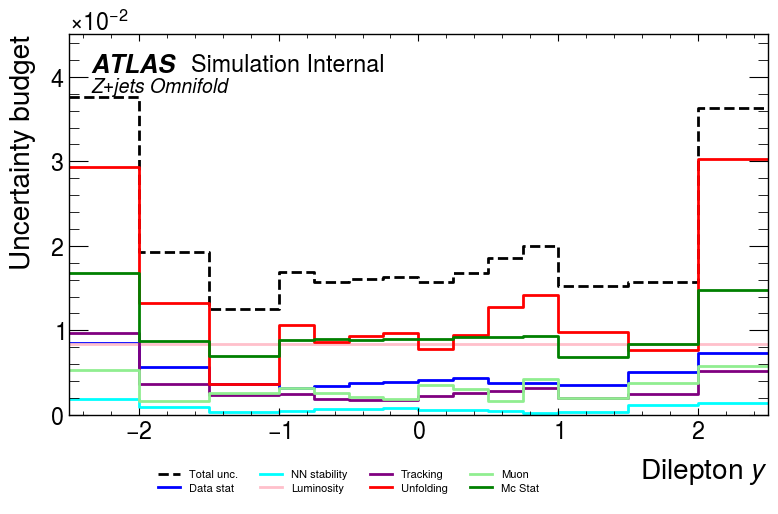

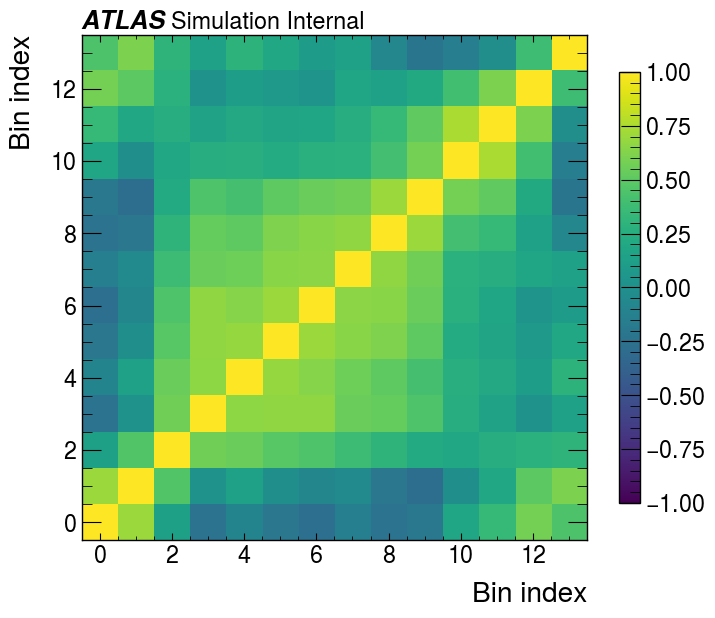

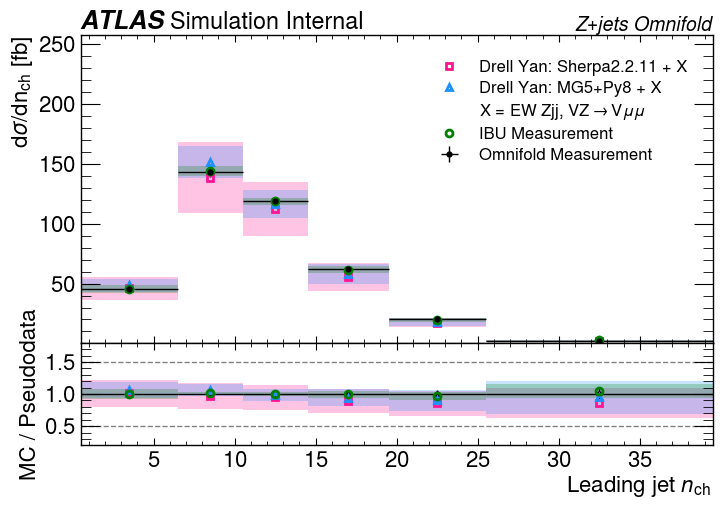

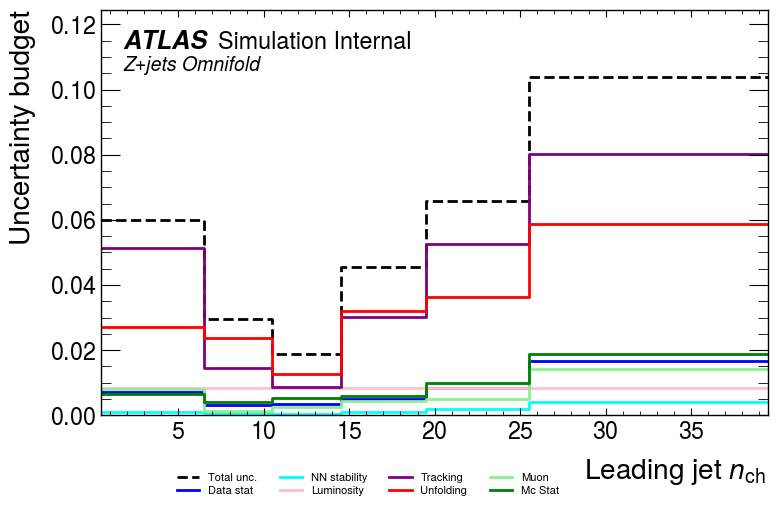

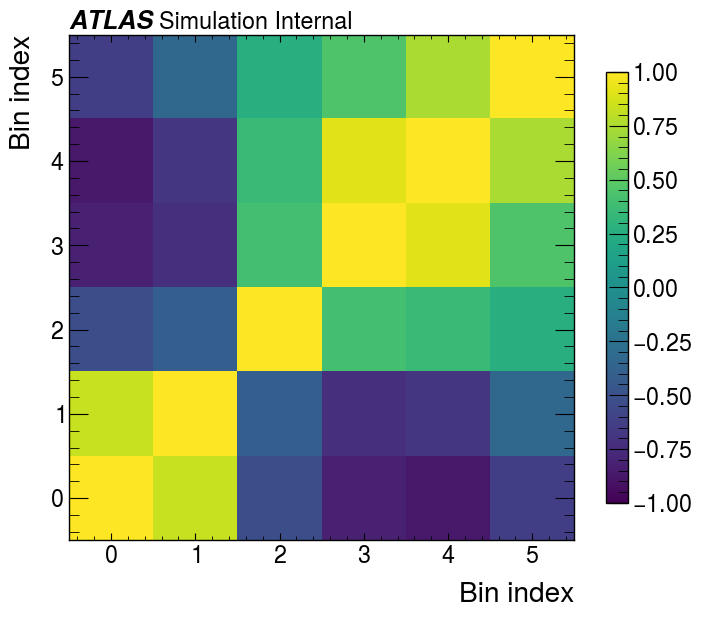

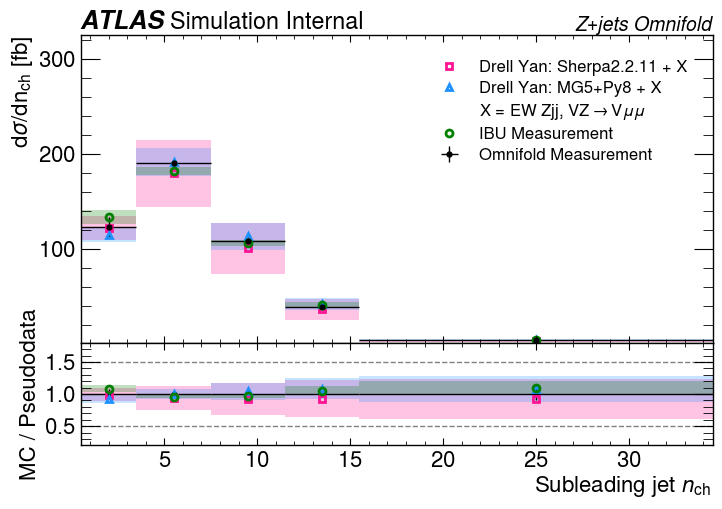

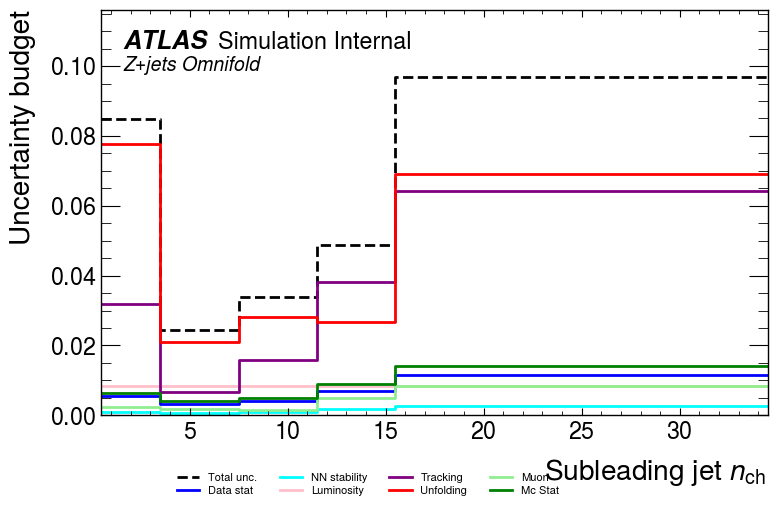

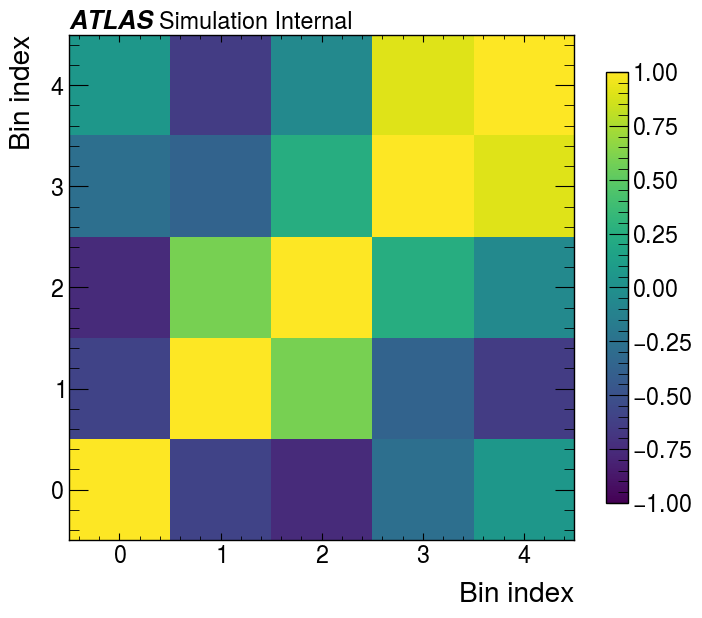

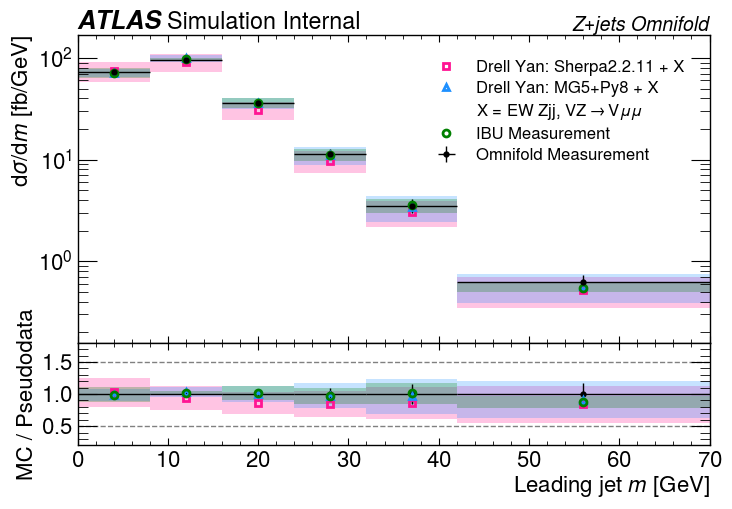

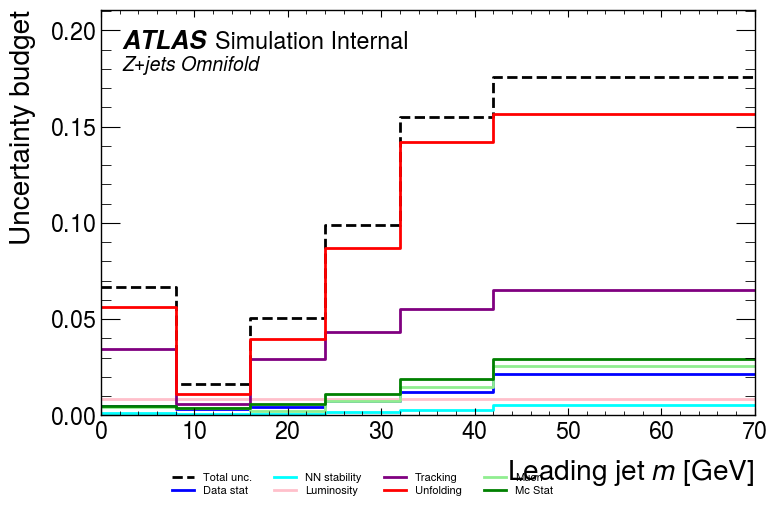

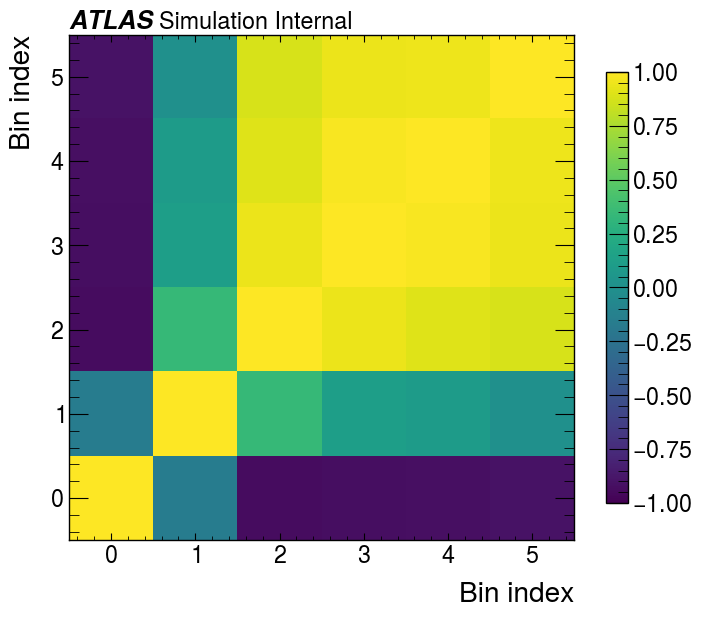

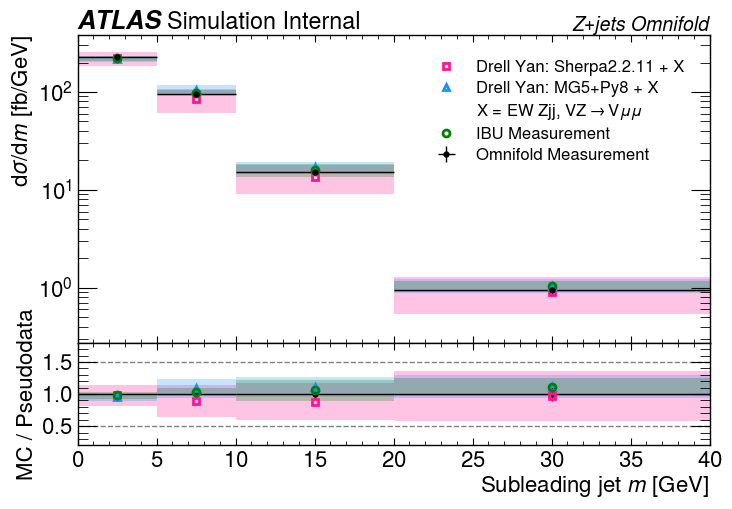

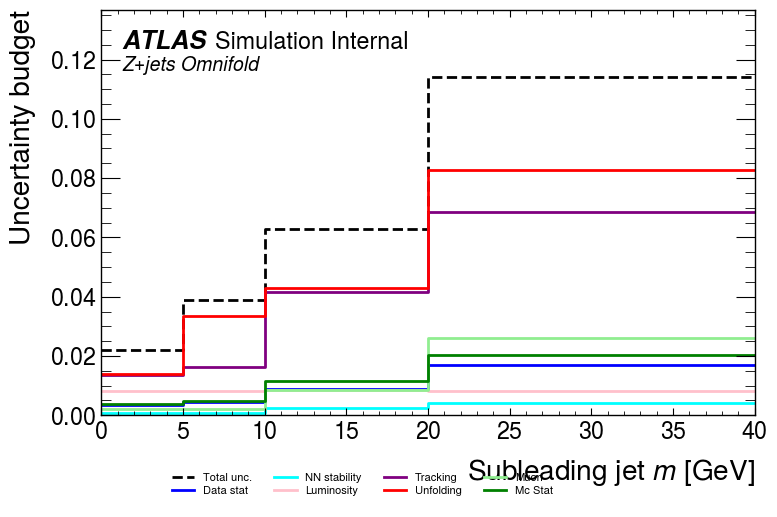

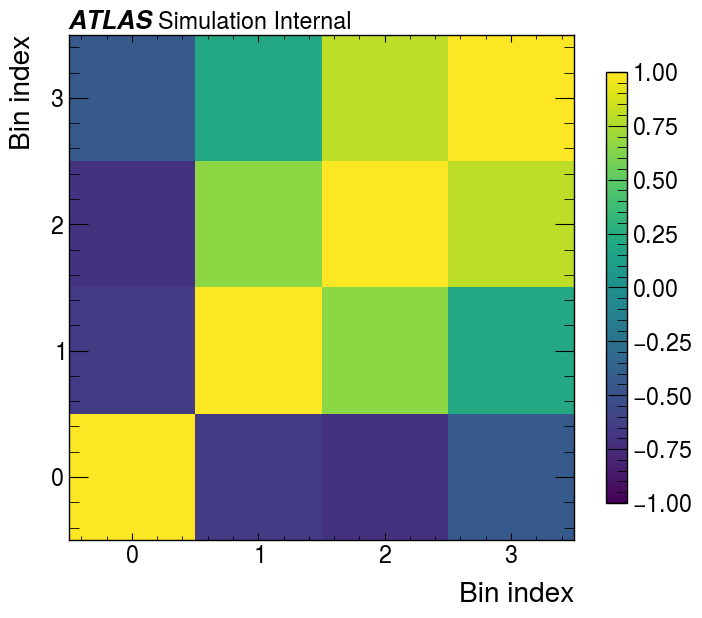

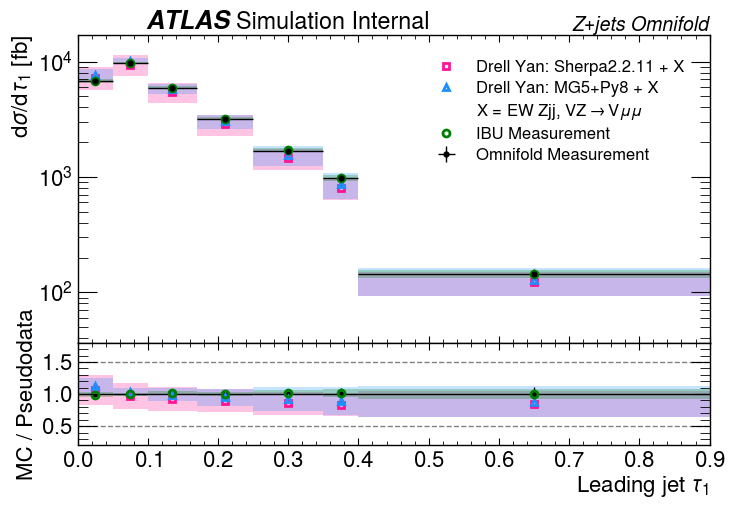

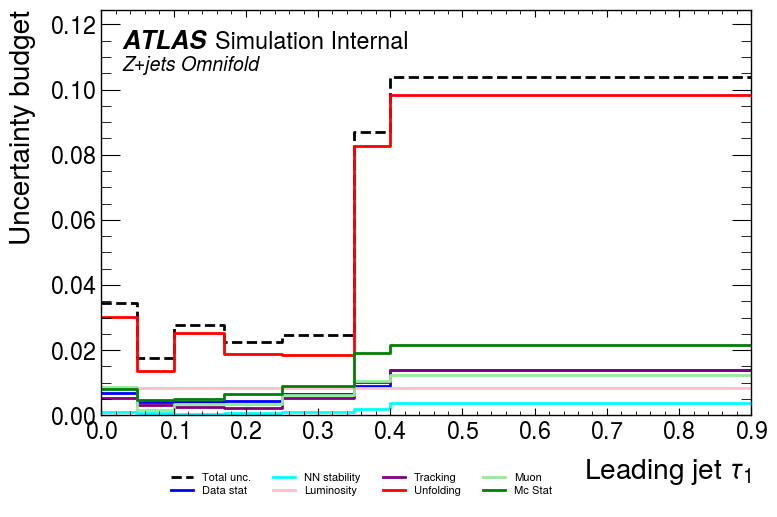

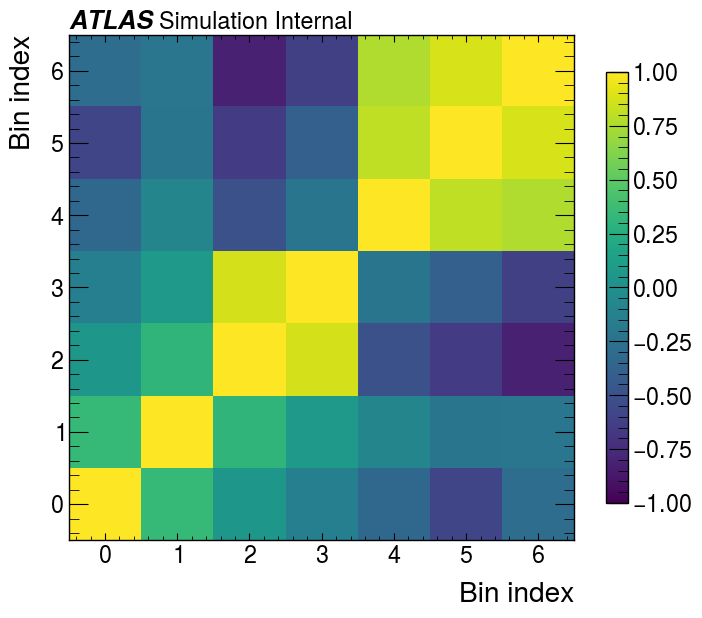

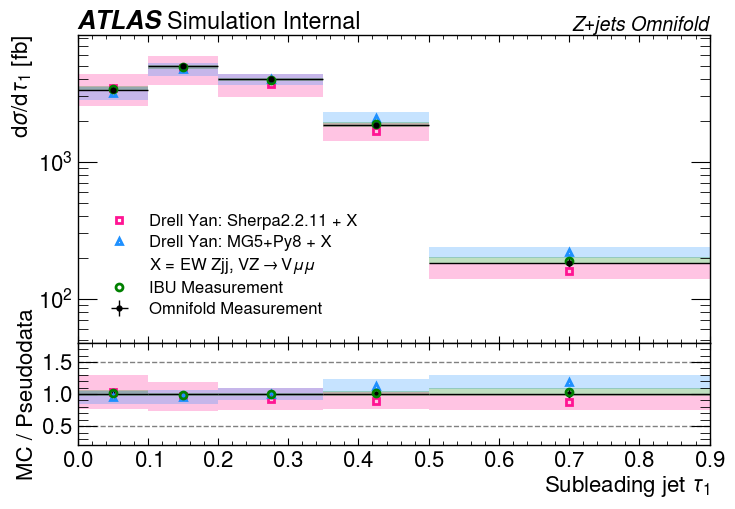

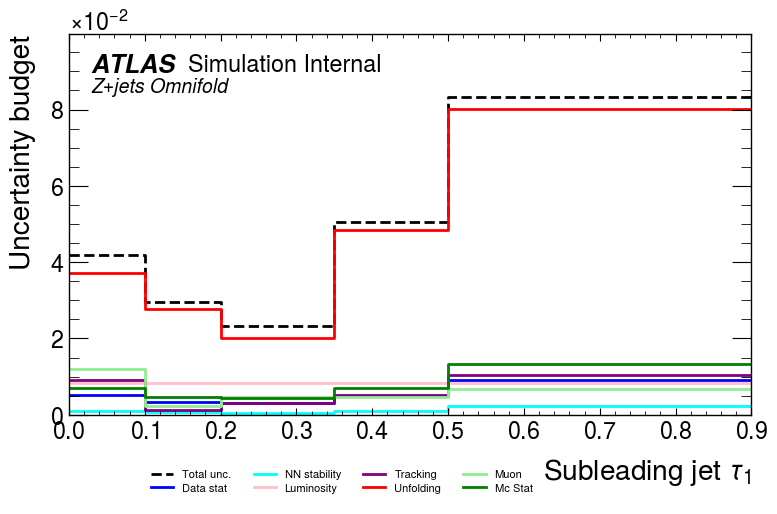

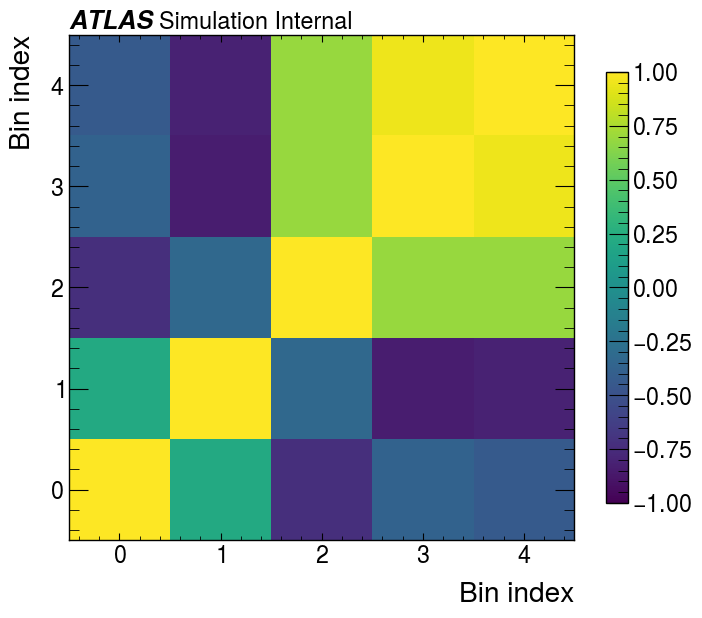

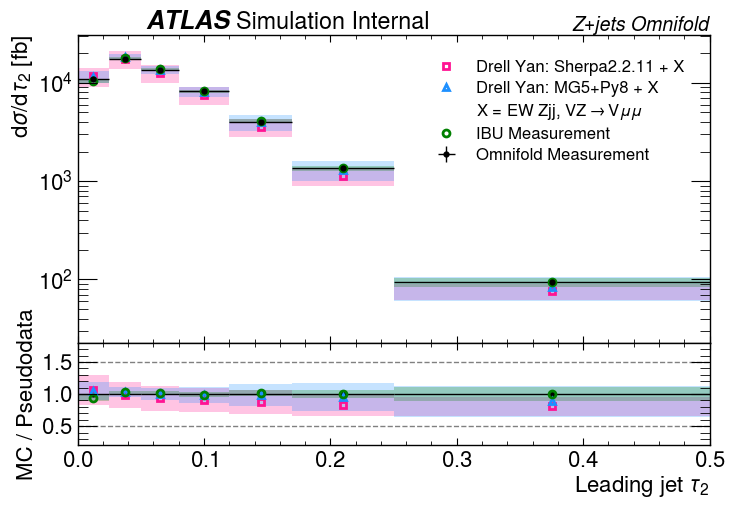

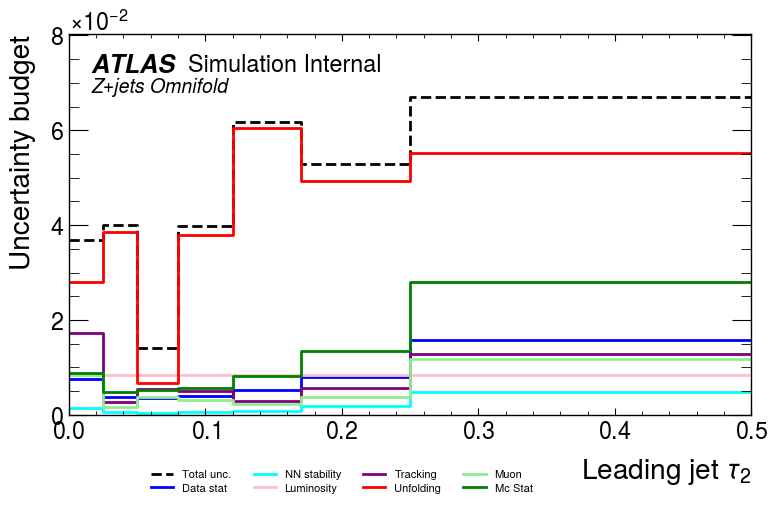

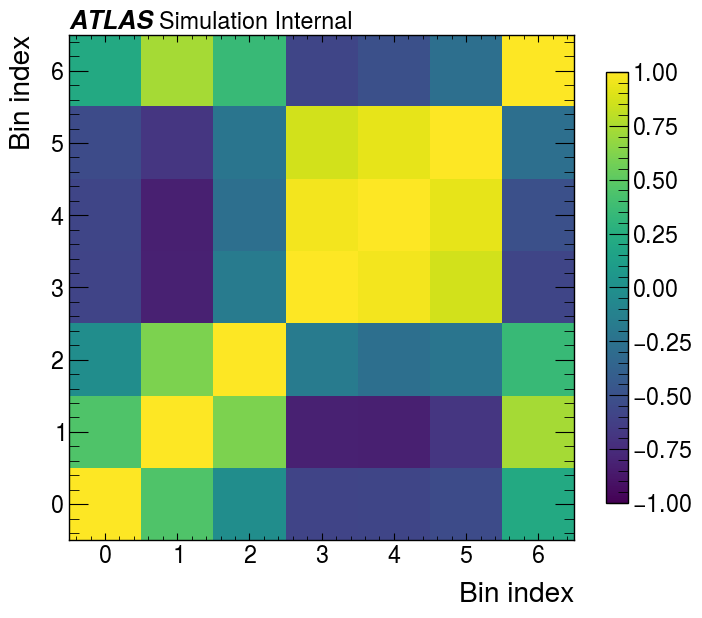

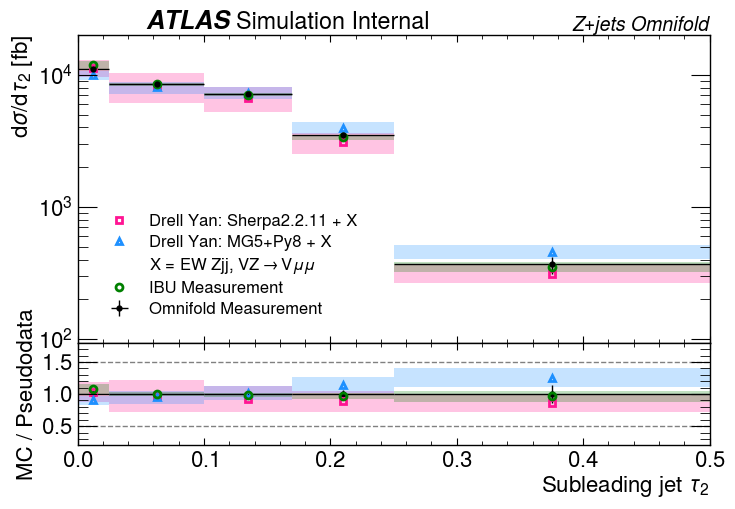

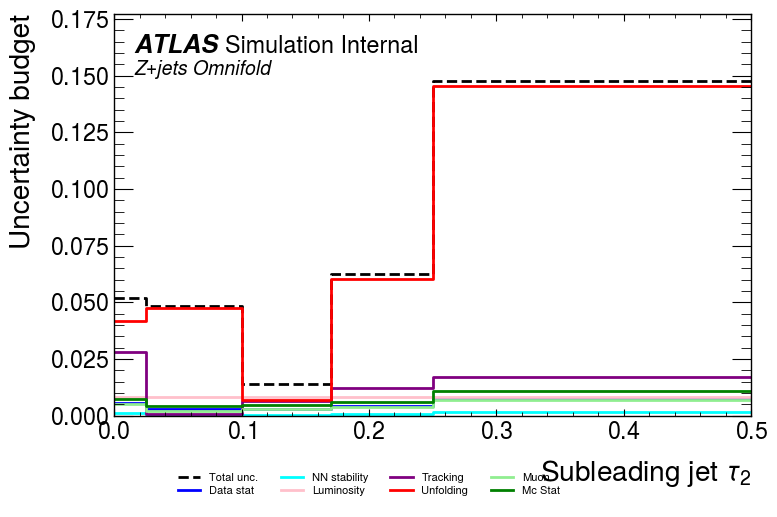

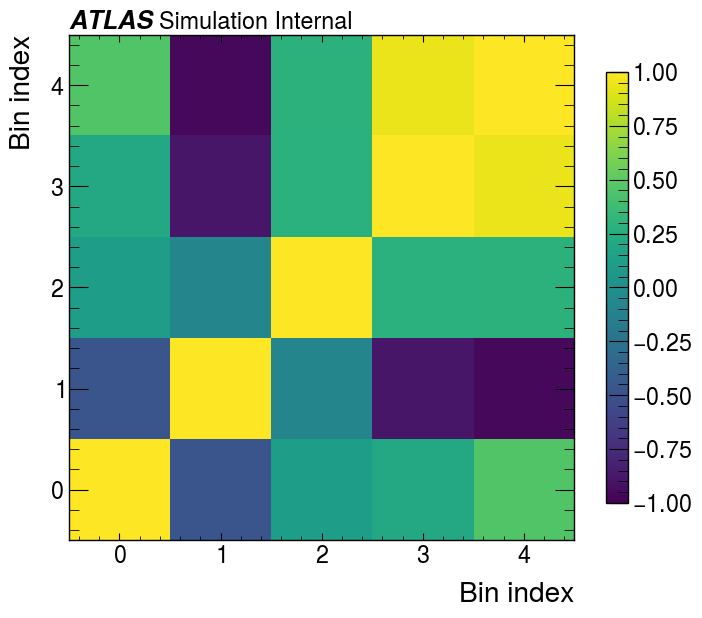

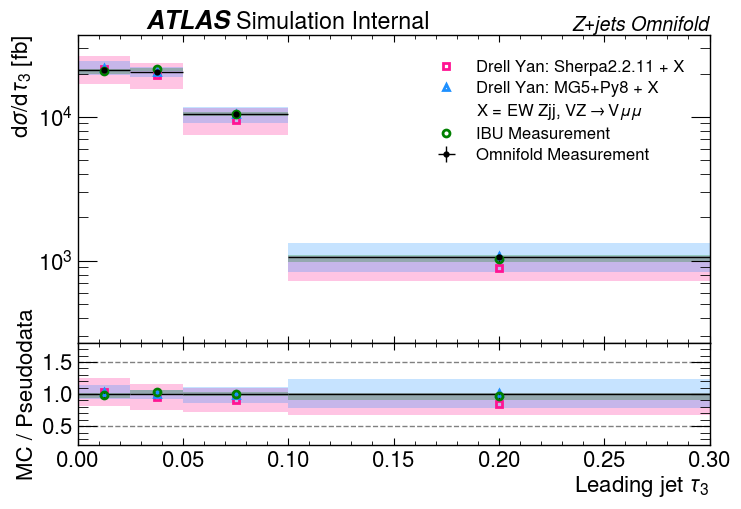

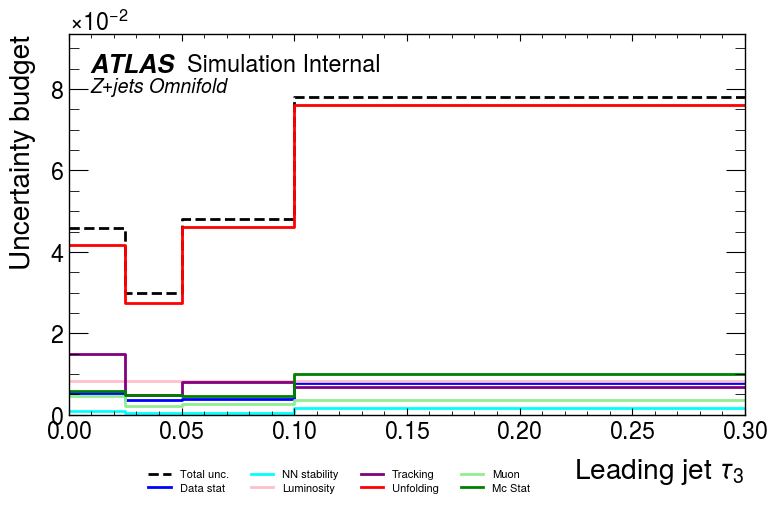

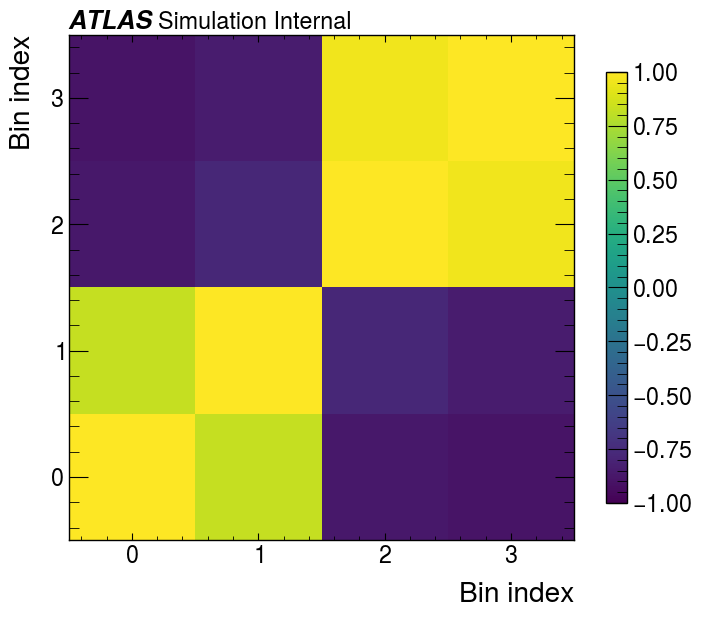

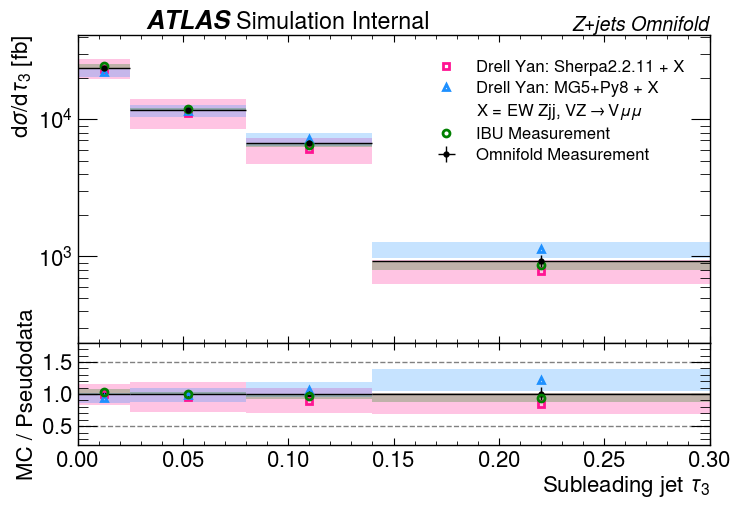

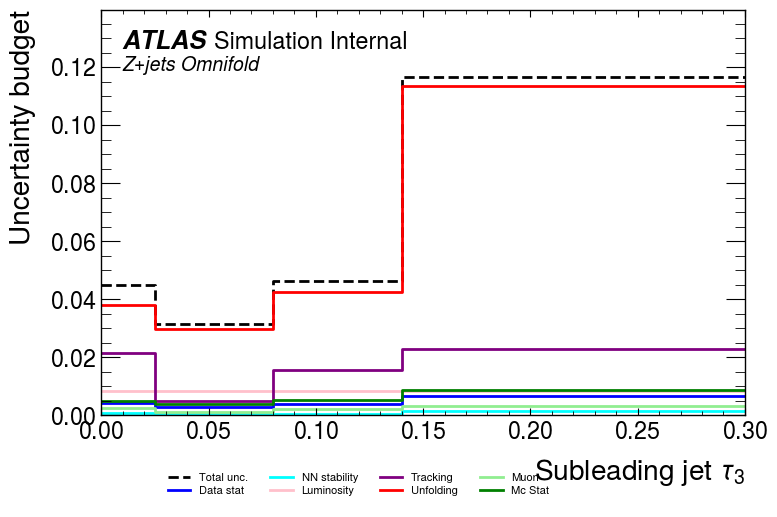

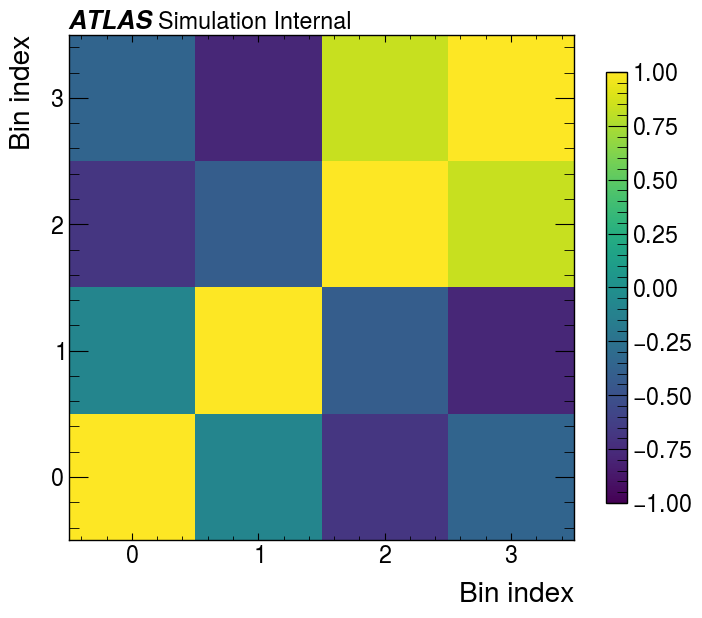

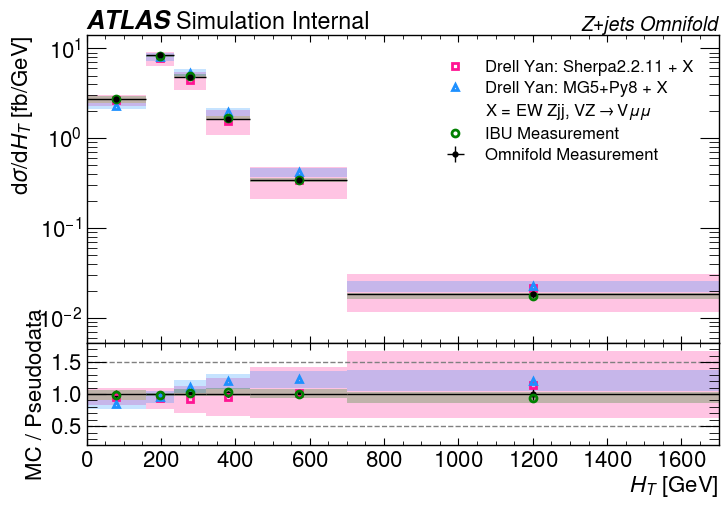

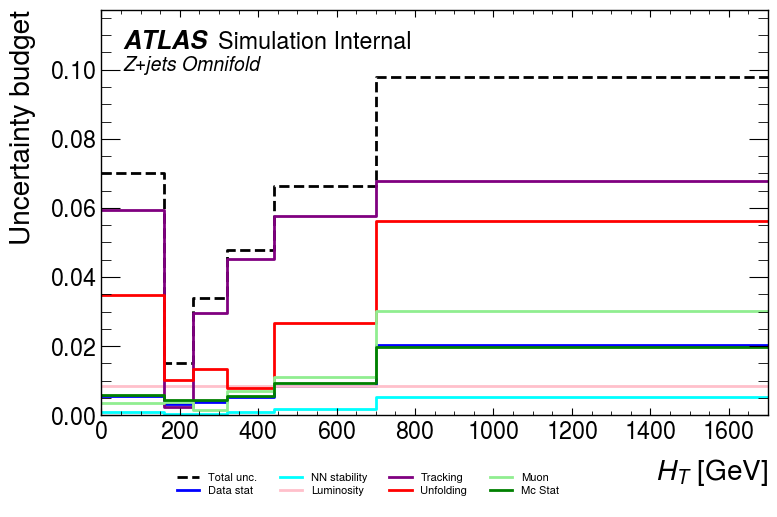

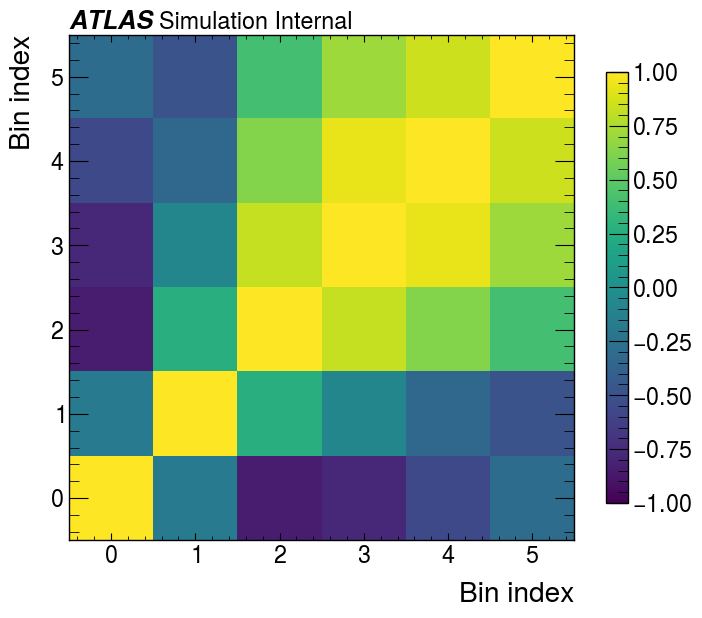

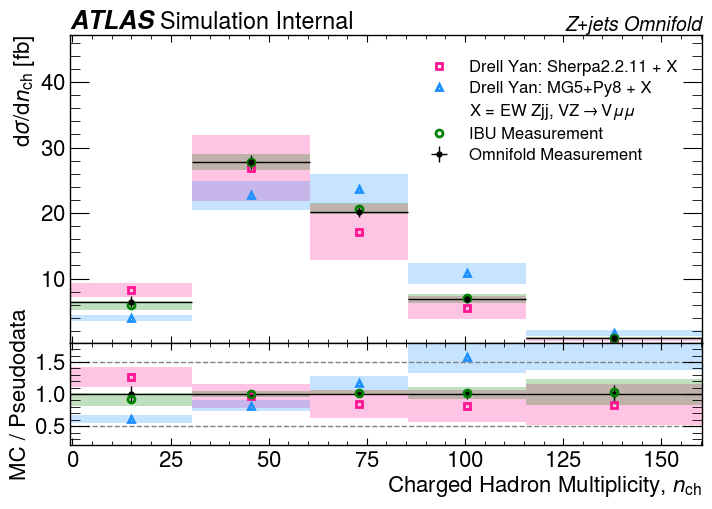

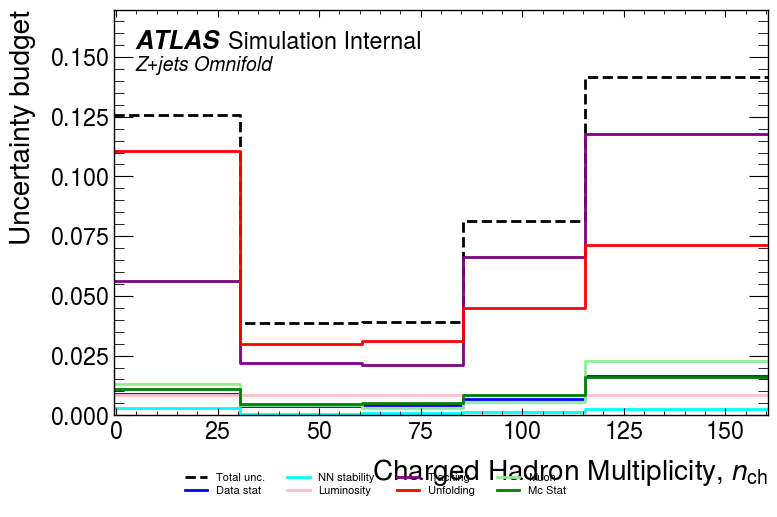

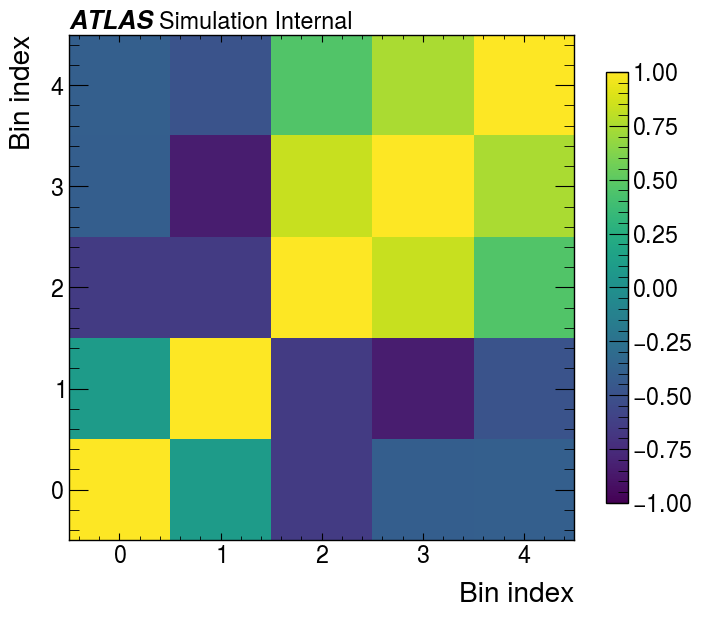

In [12]:

for feature in features:
  if is_data:
      pdf_name = "plots/data/" + feature + ".pdf"
  else:
      pdf_name = "plots/pd/" + feature + ".pdf"
  draw_plot(
      omni_results = omni_features_results[feature],
      mgfxfx_truth_results = mg_truth_features_results[feature],
      sherpa_truth_results = sh_truth_features_results[feature],
      ibu_results  = ibu_results[feature],
      binning      = ibu_bins[feature],
      ylabel       = labels[feature],
      xlabel       = plot_labels[feature],
      draw_uncertainty_budget = True,
      is_xSec      = True,
      ratio_ylim   = [0.2,1.8],
      logyScale    = features_ylog[feature],
      pdf_name     = pdf_name,
  )
